# TVision CTV Attention Analysis — Team Unified Notebook v2

**Purpose:** Rebuild the team EDA and regression analysis with corrected metric definitions and caps aligned to the client specification.

**Key changes from prior notebooks:**
- `age` capped to [5, 80] — values outside this range are treated as invalid
- `attention_seconds` and `visible_seconds` capped to `duration` (no overruns)
- New derived metric: `attention_given_visible` = `attention_seconds / visible_seconds` (engagement/tracking metric — attention conditional on the ad being visible)
- Primary KPI remains `attention_rate` = `attention_seconds / duration` (API attention rate)
- All weighted analysis uses `weight` column for population-representative inference
- Regression: OLS only (no XGBoost)

**Data:** 15 monthly weighted CSV files, Jan 2025 – Mar 2026 (~15M rows total)

**Roadmap:**
1. Setup and data loading
2. Cleaning and metric construction (caps + new metrics)
3. EDA — unweighted sample overview
4. EDA — weighted population analysis
5. OLS regression — drivers of attention_rate
6. Contextual match analysis
7. Tableau export

## 1. Setup and Data Loading

In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import Markdown, display

warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
plt.style.use("seaborn-v0_8-muted")

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 120)

# ── CAPS (change here if client updates spec) ─────────────────────────────────
AGE_MIN = 5
AGE_MAX = 80

print(f"Age cap: [{AGE_MIN}, {AGE_MAX}]")
print("attention_seconds and visible_seconds will be capped to duration")
print("Primary KPI: attention_rate = attention_seconds / duration")
print(
    "Engagement metric: attention_given_visible = attention_seconds / visible_seconds"
)

Age cap: [5, 80]
attention_seconds and visible_seconds will be capped to duration
Primary KPI: attention_rate = attention_seconds / duration
Engagement metric: attention_given_visible = attention_seconds / visible_seconds


In [2]:
# ── HELPER FUNCTIONS ──────────────────────────────────────────────────────────


def safe_divide(numerator, denominator):
    """Divide two series safely; returns NaN where denominator is 0 or NaN."""
    num = pd.to_numeric(numerator, errors="coerce")
    den = pd.to_numeric(denominator, errors="coerce")
    result = pd.Series(np.nan, index=num.index, dtype="float64")
    valid = num.notna() & den.notna() & (den > 0)
    result.loc[valid] = num.loc[valid] / den.loc[valid]
    return result


def weighted_mean(df, value_col, weight_col):
    """Weighted mean; returns NaN on empty or zero-sum weights."""
    temp = df[[value_col, weight_col]].dropna()
    if temp.empty or temp[weight_col].sum() == 0:
        return np.nan
    return (temp[value_col] * temp[weight_col]).sum() / temp[weight_col].sum()


def infer_source_month(filename: str) -> str:
    stem = Path(filename).stem
    tokens = stem.replace("-", "_").split("_")
    for idx in range(len(tokens) - 1):
        y, m = tokens[idx], tokens[idx + 1]
        if y.isdigit() and len(y) == 4 and m.isdigit() and len(m) == 2:
            return f"{y}-{m}"
    six = [t for t in tokens if t.isdigit() and len(t) == 6]
    if six:
        return f"{six[0][:4]}-{six[0][4:]}"
    return "unknown"


def is_contextual_match(row):
    """Expanded contextual match covering all major industries."""
    industry = str(row.get("industry", "")).lower()
    genre = str(row.get("content_genres", "")).lower()

    mappings = {
        "travel": ["travel", "lifestyle", "documentary", "adventure"],
        "entertainment": ["entertainment", "comedy", "drama", "reality", "talk"],
        "food": ["food", "cooking", "lifestyle", "reality"],
        "automotive": ["sports", "racing", "action", "automotive", "adventure"],
        "health": ["health", "wellness", "fitness", "medical", "documentary"],
        "finance": ["news", "business", "documentary", "talk"],
        "financial": ["news", "business", "documentary", "talk"],
        "legal": ["news", "drama", "documentary", "talk"],
        "insurance": ["news", "documentary", "drama", "talk"],
        "electronics": ["technology", "gaming", "sci-fi", "action"],
        "cosmetic": ["lifestyle", "fashion", "reality", "drama"],
        "apparel": ["lifestyle", "fashion", "reality", "drama", "sports"],
        "consumer": ["lifestyle", "reality", "comedy", "drama"],
        "restaurant": ["food", "cooking", "reality", "lifestyle"],
        "retail": ["lifestyle", "reality", "comedy", "drama", "fashion"],
        "services": ["news", "documentary", "talk", "lifestyle"],
        "telecom": ["technology", "news", "sports", "gaming"],
        "government": ["news", "documentary", "talk"],
        "education": ["documentary", "news", "education", "talk"],
        "home": ["lifestyle", "reality", "documentary", "comedy"],
        "sports": ["sports", "action", "racing", "adventure"],
    }

    for industry_key, genre_keywords in mappings.items():
        if industry_key in industry:
            if any(g in genre for g in genre_keywords):
                return 1
    return 0


# After rerunning, print coverage report
print("Expanded contextual match mapping loaded — covers all major industries.")

Expanded contextual match mapping loaded — covers all major industries.


In [3]:
import subprocess

result = subprocess.run(
    ["find", "/home", "-name", "*.csv", "-path", "*weighted*"],
    capture_output=True,
    text=True,
)
print(result.stdout[:3000])

/home/prmatta/myproject/Weighted_Datasets/weighted_data_2025_05.csv
/home/prmatta/myproject/Weighted_Datasets/weighted_data_2025_02.csv
/home/prmatta/myproject/Weighted_Datasets/weighted_data_2025_12.csv
/home/prmatta/myproject/Weighted_Datasets/weighted_data_2025_08.csv
/home/prmatta/myproject/Weighted_Datasets/weighted_data_2025_01.csv
/home/prmatta/myproject/Weighted_Datasets/weighted_data_2026_03.csv
/home/prmatta/myproject/Weighted_Datasets/weighted_data_2025_03.csv
/home/prmatta/myproject/Weighted_Datasets/weighted_data_2025_11.csv
/home/prmatta/myproject/Weighted_Datasets/weighted_data_2026_02.csv
/home/prmatta/myproject/Weighted_Datasets/weighted_data_2025_07.csv
/home/prmatta/myproject/Weighted_Datasets/weighted_data_2025_09.csv
/home/prmatta/myproject/Weighted_Datasets/weighted_data_2025_10.csv
/home/prmatta/myproject/Weighted_Datasets/weighted_data_2026_01.csv
/home/prmatta/myproject/Weighted_Datasets/weighted_data_2025_04.csv
/home/prmatta/myproject/Weighted_Datasets/weight

In [4]:
input_folder = Path("/home/prmatta/myproject/Weighted_Datasets")
all_files = sorted(
    [fp for fp in input_folder.glob("*.csv") if "weighted" in fp.name.lower()]
)

print(f"Input folder: {input_folder.resolve()}")
print(f"Files found: {len(all_files)}")

if not all_files:
    raise FileNotFoundError("No weighted CSV files found in Weighted_Datasets/")

loaded_dfs = []
load_log = []
for fp in all_files:
    try:
        df = pd.read_csv(fp)
        df["source_file"] = fp.name
        df["source_month"] = infer_source_month(fp.name)
        loaded_dfs.append(df)
        load_log.append(
            {"file": fp.name, "rows": len(df), "cols": df.shape[1], "status": "loaded"}
        )
    except Exception as e:
        load_log.append(
            {"file": fp.name, "rows": 0, "cols": 0, "status": f"ERROR: {e}"}
        )

master_df = pd.concat(loaded_dfs, ignore_index=True)

print(f"\nTotal rows loaded: {len(master_df):,}")
display(pd.DataFrame(load_log))

Input folder: /home/prmatta/myproject/Weighted_Datasets
Files found: 15

Total rows loaded: 15,000,000


,file,rows,cols,status
0,weighted_data_2025_01.csv,1000000,24,loaded
1,weighted_data_2025_02.csv,1000000,24,loaded
2,weighted_data_2025_03.csv,1000000,24,loaded
3,weighted_data_2025_04.csv,1000000,24,loaded
4,weighted_data_2025_05.csv,1000000,24,loaded
5,weighted_data_2025_06.csv,1000000,24,loaded
6,weighted_data_2025_07.csv,1000000,24,loaded
7,weighted_data_2025_08.csv,1000000,24,loaded
8,weighted_data_2025_09.csv,1000000,24,loaded
9,weighted_data_2025_10.csv,1000000,24,loaded


## 2. Cleaning and Metric Construction

**Caps applied in this section:**
1. **Age** → values outside [5, 80] set to NaN
2. **attention_seconds** → capped at `duration` (overruns set to `duration`)
3. **visible_seconds** → capped at `duration` (overruns set to `duration`)

**Metrics constructed:**
- `attention_rate` = `attention_seconds / duration` → API attention rate (primary KPI)
- `visible_rate` = `visible_seconds / duration` → visibility rate
- `attention_given_visible` = `attention_seconds / visible_seconds` → engagement/tracking metric (attention conditional on visibility)

In [5]:
cleaned_df = master_df.copy()

# Detect key columns
duration_col = next(
    (c for c in ["duration_seconds", "duration"] if c in cleaned_df.columns), None
)
weight_col = next(
    (c for c in ["weight", "weights", "sample_weight"] if c in cleaned_df.columns), None
)
viewer_id = next(
    (c for c in ["demo_id", "viewer_id", "person_id"] if c in cleaned_df.columns), None
)
hh_col = next((c for c in ["hh_id", "household_id"] if c in cleaned_df.columns), None)

print(f"duration col  : {duration_col}")
print(f"weight col    : {weight_col}")
print(f"viewer id col : {viewer_id}")
print(f"household col : {hh_col}")

if duration_col is None:
    raise ValueError(
        "No duration column found — required for capping and rate metrics."
    )

# ── Pre-clean counts ──────────────────────────────────────────────────────────
pre = {
    "age_below_min": int((cleaned_df["age"] < AGE_MIN).sum())
    if "age" in cleaned_df.columns
    else 0,
    "age_above_max": int((cleaned_df["age"] > AGE_MAX).sum())
    if "age" in cleaned_df.columns
    else 0,
    "age_zero": int((cleaned_df["age"] == 0).sum())
    if "age" in cleaned_df.columns
    else 0,
    "attention_gt_duration": int(
        (cleaned_df["attention_seconds"] > cleaned_df[duration_col]).sum()
    )
    if "attention_seconds" in cleaned_df.columns
    else 0,
    "visible_gt_duration": int(
        (cleaned_df["visible_seconds"] > cleaned_df[duration_col]).sum()
    )
    if "visible_seconds" in cleaned_df.columns
    else 0,
}

# ── CAP 1: Age ────────────────────────────────────────────────────────────────
if "age" in cleaned_df.columns:
    outside_age = (cleaned_df["age"] < AGE_MIN) | (cleaned_df["age"] > AGE_MAX)
    cleaned_df.loc[outside_age, "age"] = np.nan
    # Also nullify age=0 (sentinel for missing)
    cleaned_df.loc[cleaned_df["age"] == 0, "age"] = np.nan

# ── CAP 2: attention_seconds ≤ duration ───────────────────────────────────────
if "attention_seconds" in cleaned_df.columns:
    over = cleaned_df["attention_seconds"] > cleaned_df[duration_col]
    cleaned_df.loc[over, "attention_seconds"] = cleaned_df.loc[over, duration_col]

# ── CAP 3: visible_seconds ≤ duration ────────────────────────────────────────
if "visible_seconds" in cleaned_df.columns:
    over = cleaned_df["visible_seconds"] > cleaned_df[duration_col]
    cleaned_df.loc[over, "visible_seconds"] = cleaned_df.loc[over, duration_col]

# ── METRIC CONSTRUCTION ───────────────────────────────────────────────────────
# Primary KPI: API attention rate
cleaned_df["attention_rate"] = safe_divide(
    cleaned_df["attention_seconds"], cleaned_df[duration_col]
)

# Visibility rate
cleaned_df["visible_rate"] = safe_divide(
    cleaned_df["visible_seconds"], cleaned_df[duration_col]
)

# Engagement/tracking metric: attention GIVEN visibility
# Definition: attention_seconds / visible_seconds
# Interpretation: of the time the ad was visible, how much was the viewer actually paying attention?
cleaned_df["attention_given_visible"] = safe_divide(
    cleaned_df["attention_seconds"], cleaned_df["visible_seconds"]
)

# ── Post-clean validation ─────────────────────────────────────────────────────
post = {
    "age_out_of_range": int(cleaned_df["age"].isna().sum())
    if "age" in cleaned_df.columns
    else 0,
    "attention_gt_duration": int(
        (cleaned_df["attention_seconds"] > cleaned_df[duration_col]).sum()
    )
    if "attention_seconds" in cleaned_df.columns
    else 0,
    "visible_gt_duration": int(
        (cleaned_df["visible_seconds"] > cleaned_df[duration_col]).sum()
    )
    if "visible_seconds" in cleaned_df.columns
    else 0,
}

validation_log = pd.DataFrame(
    [
        {"check": "age < 5 (set to NaN)", "before": pre["age_below_min"], "after": 0},
        {"check": "age > 80 (set to NaN)", "before": pre["age_above_max"], "after": 0},
        {"check": "age == 0 (set to NaN)", "before": pre["age_zero"], "after": 0},
        {
            "check": "attention_seconds > duration",
            "before": pre["attention_gt_duration"],
            "after": post["attention_gt_duration"],
        },
        {
            "check": "visible_seconds > duration",
            "before": pre["visible_gt_duration"],
            "after": post["visible_gt_duration"],
        },
    ]
)

print("\n=== CLEANING VALIDATION ===")
display(validation_log)

print("\n=== METRIC SUMMARY ===")
display(
    cleaned_df[["attention_rate", "visible_rate", "attention_given_visible"]]
    .describe()
    .round(4)
    .T
)

duration col  : duration
weight col    : weight
viewer id col : demo_id
household col : hh_id

=== CLEANING VALIDATION ===


,check,before,after
0,age < 5 (set to NaN),27163,0
1,age > 80 (set to NaN),451659,0
2,age == 0 (set to NaN),858,0
3,attention_seconds > duration,112096,0
4,visible_seconds > duration,317515,0



=== METRIC SUMMARY ===


,count,mean,std,min,25%,50%,75%,max
attention_rate,14999524.0,0.3519,0.3947,0.0,0.0000,0.1333,0.75,1.0
visible_rate,14999524.0,0.6613,0.4240,0.0,0.1667,1.0000,1.00,1.0
attention_given_visible,11949887.0,0.5178,0.4106,0.0,0.0357,0.5333,1.00,1.0


In [6]:
# ── Date feature engineering ──────────────────────────────────────────────────
datetime_col = next(
    (
        c
        for c in [
            "viewing_start_time_local",
            "viewing_start_time",
            "timestamp",
            "start_time",
        ]
        if c in cleaned_df.columns
    ),
    None,
)

if datetime_col:
    parsed = pd.to_datetime(cleaned_df[datetime_col], errors="coerce")
    cleaned_df["day_name"] = parsed.dt.day_name()
    cleaned_df["is_weekend"] = parsed.dt.dayofweek.isin([5, 6])
    cleaned_df["hour_of_day"] = parsed.dt.hour
    print(f"Date features derived from: {datetime_col}")
else:
    print(
        "No datetime column detected — day_name, is_weekend, hour_of_day not created."
    )

# ── Contextual match flag ─────────────────────────────────────────────────────
if "industry" in cleaned_df.columns and "content_genres" in cleaned_df.columns:
    cleaned_df["contextual_match"] = cleaned_df.apply(is_contextual_match, axis=1)
    print(
        f"Contextual match distribution:\n{cleaned_df['contextual_match'].value_counts().to_string()}"
    )
    print(f"Match rate: {cleaned_df['contextual_match'].mean():.1%}")
else:
    cleaned_df["contextual_match"] = np.nan
    print("industry or content_genres column missing — contextual_match not created.")

print(f"\nFinal cleaned_df shape: {cleaned_df.shape}")

# ── Coverage report by industry ───────────────────────────────────────────────
if "industry" in cleaned_df.columns and "contextual_match" in cleaned_df.columns:
    coverage = (
        cleaned_df.groupby("industry")["contextual_match"]
        .mean()
        .round(4)
        .reset_index()
        .rename(columns={"contextual_match": "match_rate"})
        .sort_values("match_rate", ascending=False)
    )
    coverage["match_rate_pct"] = (coverage["match_rate"] * 100).round(1).astype(
        str
    ) + "%"
    print("\n=== CONTEXTUAL MATCH COVERAGE BY INDUSTRY ===")
    display(coverage)

Date features derived from: viewing_start_time_local
Contextual match distribution:
contextual_match
0    8975228
1    6024772
Match rate: 40.2%

Final cleaned_df shape: (15000000, 31)

=== CONTEXTUAL MATCH COVERAGE BY INDUSTRY ===


,industry,match_rate,match_rate_pct
0,Apparel / Footwear / Accessories,0.6503,65.0%
13,Legal,0.6418,64.2%
2,Consumer Products,0.6132,61.3%
6,Entertainment / Media / Leisure,0.6081,60.8%
17,Services,0.5670,56.7%
14,Legal / Financial,0.5371,53.7%
9,Government / Organizations,0.5047,50.5%
20,legal,0.5000,50.0%
18,Telecommunications,0.4577,45.8%
3,Cosmetic / Hygiene,0.4377,43.8%


## 3. EDA — Unweighted Sample Overview

=== OVERALL KPIs (UNWEIGHTED) ===


,count,mean,std,min,25%,50%,75%,max
attention_rate,14999524.0,0.3519,0.3947,0.0,0.0000,0.1333,0.75,1.0
visible_rate,14999524.0,0.6613,0.4240,0.0,0.1667,1.0000,1.00,1.0
attention_given_visible,11949887.0,0.5178,0.4106,0.0,0.0357,0.5333,1.00,1.0


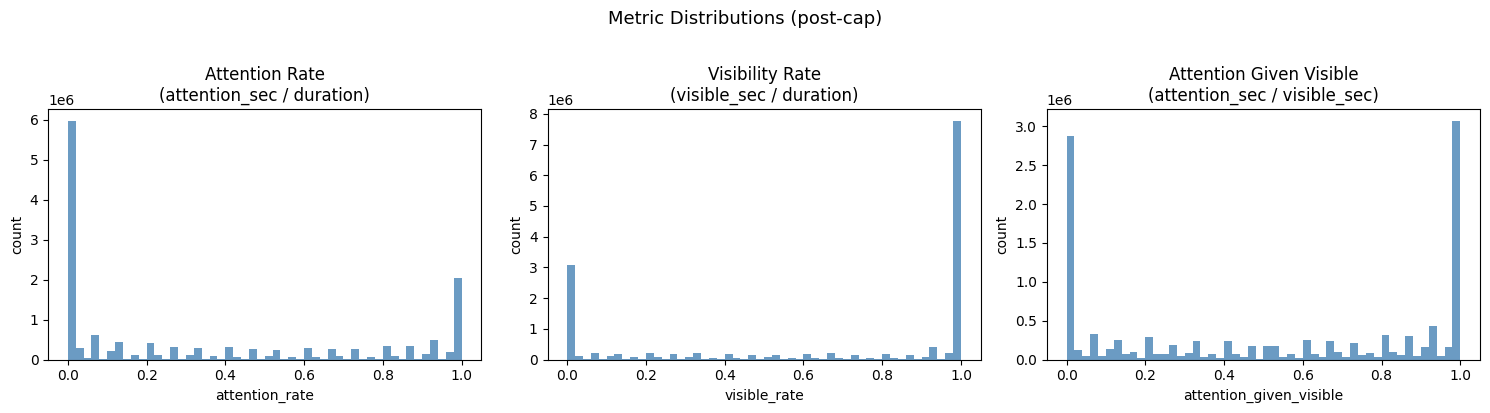

In [7]:
# ── Overall KPIs ──────────────────────────────────────────────────────────────
print("=== OVERALL KPIs (UNWEIGHTED) ===")
kpi_cols = ["attention_rate", "visible_rate", "attention_given_visible"]
display(cleaned_df[kpi_cols].describe().round(4).T)

# ── KPI distributions ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = {
    "attention_rate": "Attention Rate\n(attention_sec / duration)",
    "visible_rate": "Visibility Rate\n(visible_sec / duration)",
    "attention_given_visible": "Attention Given Visible\n(attention_sec / visible_sec)",
}
for ax, col in zip(axes, kpi_cols):
    if col in cleaned_df.columns:
        cleaned_df[col].dropna().plot(
            kind="hist", bins=50, ax=ax, color="steelblue", alpha=0.8
        )
        ax.set_title(labels[col])
        ax.set_xlabel(col)
        ax.set_ylabel("count")
fig.suptitle("Metric Distributions (post-cap)", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

In [8]:
# ── Attention rate by key categorical variables ───────────────────────────────
cat_vars = [
    c
    for c in [
        "source_type",
        "industry",
        "daypart",
        "gender",
        "series_movie_ind",
        "source_category",
        "day_name",
    ]
    if c in cleaned_df.columns
]

for col in cat_vars:
    summary = (
        cleaned_df.groupby(col)["attention_rate"]
        .agg(
            row_count="count",
            mean_attention_rate="mean",
            median_attention_rate="median",
        )
        .sort_values("mean_attention_rate", ascending=False)
        .round(4)
        .reset_index()
    )
    print(f"\nUnweighted attention_rate by {col}:")
    display(summary)

# ── Attention given visible by source_type ────────────────────────────────────
if "source_type" in cleaned_df.columns:
    print("\nAttention GIVEN VISIBLE by source_type (engagement metric):")
    display(
        cleaned_df.groupby("source_type")["attention_given_visible"]
        .agg(row_count="count", mean="mean", median="median")
        .round(4)
        .sort_values("mean", ascending=False)
    )

# ── CTV vs Linear: visibility vs engagement decomposition ────────────────────
if "source_type" in cleaned_df.columns:
    print("\n=== CTV vs LINEAR: VISIBILITY vs ENGAGEMENT DECOMPOSITION ===\n")

    ctv_lin = (
        cleaned_df.groupby("source_type")
        .agg(
            row_count=("attention_rate", "count"),
            attention_rate=("attention_rate", "mean"),
            visible_rate=("visible_rate", "mean"),
            attention_given_visible=("attention_given_visible", "mean"),
        )
        .round(4)
    )

    ctv_lin["attention_gap_vs_linear"] = (
        ctv_lin["attention_rate"] - ctv_lin.loc["linear", "attention_rate"]
    ).round(4)

    display(ctv_lin)

    linear_attn = ctv_lin.loc["linear", "attention_rate"]
    ctv_attn = ctv_lin.loc["ctv", "attention_rate"]
    linear_vis = ctv_lin.loc["linear", "visible_rate"]
    ctv_vis = ctv_lin.loc["ctv", "visible_rate"]
    linear_eng = ctv_lin.loc["linear", "attention_given_visible"]
    ctv_eng = ctv_lin.loc["ctv", "attention_given_visible"]

    print(f"""
KEY INSIGHT — CTV'S PROBLEM IS VISIBILITY, NOT ENGAGEMENT QUALITY:

  Overall attention gap (Linear - CTV):  {(linear_attn - ctv_attn) * 100:+.1f} pp
  Visibility gap (Linear - CTV):         {(linear_vis - ctv_vis) * 100:+.1f} pp
  Engagement gap (Linear - CTV):         {(linear_eng - ctv_eng) * 100:+.1f} pp

  → CTV ads are seen {(linear_vis - ctv_vis) * 100:.1f}pp less often than Linear ads
  → BUT when a CTV ad IS visible, viewers pay {(ctv_eng - linear_eng) * 100:.1f}pp MORE
    attention than on Linear

  Implication: CTV's attention deficit is a DELIVERY problem (viewability,
  placement, screen environment) — not an audience engagement problem.
  Improving CTV ad placement and viewability would close most of the gap.
""")


Unweighted attention_rate by source_type:


,source_type,row_count,mean_attention_rate,median_attention_rate
0,linear,14898048,0.3523,0.1333
1,ctv,101476,0.2813,0.0667



Unweighted attention_rate by industry:


,industry,row_count,mean_attention_rate,median_attention_rate
0,Entertainment / Media / Leisure,3526557,0.3682,0.2000
1,Apparel / Footwear / Accessories,47300,0.3672,0.1667
2,Travel,279270,0.3588,0.1667
3,Food / Beverages,876142,0.3551,0.1333
4,Consumer Products,924166,0.3534,0.1333
5,Restaurants,896391,0.3514,0.1333
6,Cosmetic / Hygiene,532463,0.3501,0.1333
7,Retail,1432103,0.3492,0.1333
8,Automotive / Vehicles,820995,0.3465,0.1333
9,Telecommunications,368166,0.3464,0.1333



Unweighted attention_rate by daypart:


...


Attention GIVEN VISIBLE by source_type (engagement metric):


,row_count,mean,median
source_type,,,
ctv,75147,0.5354,0.6000
linear,11874740,0.5177,0.5333



=== CTV vs LINEAR: VISIBILITY vs ENGAGEMENT DECOMPOSITION ===



,row_count,attention_rate,visible_rate,attention_given_visible,attention_gap_vs_linear
source_type,,,,,
ctv,101476,0.2813,0.5034,0.5354,-0.071
linear,14898048,0.3523,0.6624,0.5177,0.000



KEY INSIGHT — CTV'S PROBLEM IS VISIBILITY, NOT ENGAGEMENT QUALITY:

  Overall attention gap (Linear - CTV):  +7.1 pp
  Visibility gap (Linear - CTV):         +15.9 pp
  Engagement gap (Linear - CTV):         -1.8 pp

  → CTV ads are seen 15.9pp less often than Linear ads
  → BUT when a CTV ad IS visible, viewers pay 1.8pp MORE
    attention than on Linear

  Implication: CTV's attention deficit is a DELIVERY problem (viewability,
  placement, screen environment) — not an audience engagement problem.
  Improving CTV ad placement and viewability would close most of the gap.



=== AGE DISTRIBUTION (post-cap: 5–80) ===
Valid age records: 14,521,178 (96.81%)
Age range: [5, 80]
Mean age: 58.2 | Median: 60

Attention rate by age group:


,age_group,row_count,mean_attention_rate
0,5-17,288088,0.2526
1,18-24,256312,0.2709
2,25-34,307002,0.3009
3,35-44,1252163,0.3020
4,45-54,2713824,0.3275
5,55-64,4365772,0.3552
6,65-80,5332350,0.3805


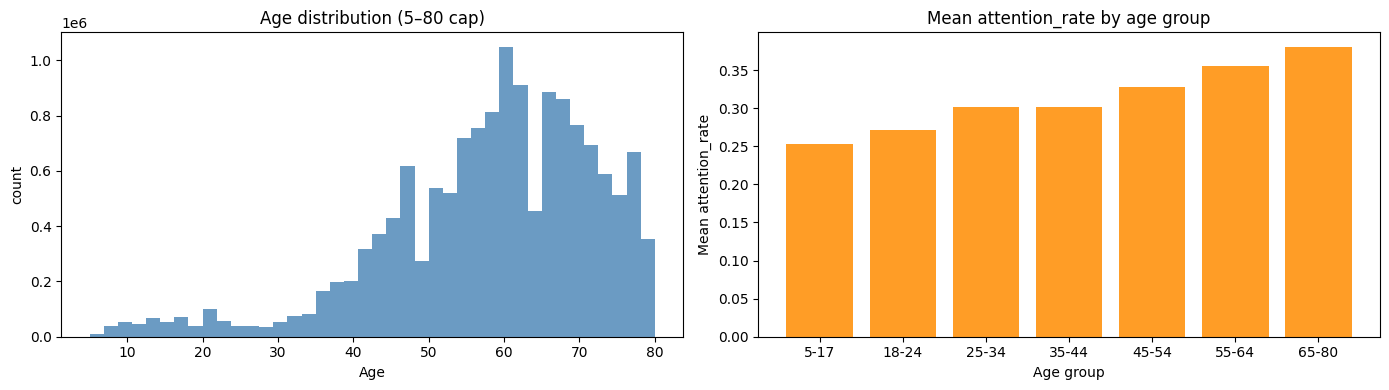

In [9]:
# ── Age analysis (post-cap: 5-80 only) ───────────────────────────────────────
if "age" in cleaned_df.columns:
    print("=== AGE DISTRIBUTION (post-cap: 5–80) ===")
    age_valid = cleaned_df["age"].dropna()
    print(
        f"Valid age records: {len(age_valid):,} ({len(age_valid) / len(cleaned_df):.2%})"
    )
    print(f"Age range: [{age_valid.min():.0f}, {age_valid.max():.0f}]")
    print(f"Mean age: {age_valid.mean():.1f} | Median: {age_valid.median():.0f}")

    # Age bins vs attention
    cleaned_df["age_group"] = pd.cut(
        cleaned_df["age"],
        bins=[5, 17, 24, 34, 44, 54, 64, 80],
        labels=["5-17", "18-24", "25-34", "35-44", "45-54", "55-64", "65-80"],
    )
    age_attention = (
        cleaned_df.groupby("age_group", observed=True)["attention_rate"]
        .agg(row_count="count", mean_attention_rate="mean")
        .round(4)
        .reset_index()
    )
    print("\nAttention rate by age group:")
    display(age_attention)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].hist(age_valid, bins=40, color="steelblue", alpha=0.8)
    axes[0].set_title("Age distribution (5–80 cap)")
    axes[0].set_xlabel("Age")
    axes[0].set_ylabel("count")

    axes[1].bar(
        age_attention["age_group"].astype(str),
        age_attention["mean_attention_rate"],
        color="darkorange",
        alpha=0.85,
    )
    axes[1].set_title("Mean attention_rate by age group")
    axes[1].set_xlabel("Age group")
    axes[1].set_ylabel("Mean attention_rate")
    fig.tight_layout()
    plt.show()

## 4. EDA — Weighted Population Analysis

All results in this section use `weight` for population-representative inference. These are the numbers to use for client-facing reporting.

In [10]:
# ── Overall weighted KPIs ─────────────────────────────────────────────────────
if weight_col:
    w_attn = weighted_mean(cleaned_df, "attention_rate", weight_col)
    w_vis = weighted_mean(cleaned_df, "visible_rate", weight_col)
    w_eng = weighted_mean(cleaned_df, "attention_given_visible", weight_col)
    uw_attn = cleaned_df["attention_rate"].mean()

    print("=== WEIGHTED POPULATION-LEVEL KPIs ===")
    kpi_df = pd.DataFrame(
        [
            {
                "KPI": "Attention Rate (primary)",
                "Unweighted": f"{uw_attn:.4f}",
                "Weighted": f"{w_attn:.4f}",
            },
            {
                "KPI": "Visibility Rate",
                "Unweighted": f"{cleaned_df['visible_rate'].mean():.4f}",
                "Weighted": f"{w_vis:.4f}",
            },
            {
                "KPI": "Attention Given Visible (engagement)",
                "Unweighted": f"{cleaned_df['attention_given_visible'].mean():.4f}",
                "Weighted": f"{w_eng:.4f}",
            },
        ]
    )
    display(kpi_df)
    print(f"\nWeighted vs unweighted attention gap: {(w_attn - uw_attn) * 100:+.2f} pp")
else:
    print("Weight column not found — weighted analysis skipped.")

=== WEIGHTED POPULATION-LEVEL KPIs ===


,KPI,Unweighted,Weighted
0,Attention Rate (primary),0.3519,0.3531
1,Visibility Rate,0.6613,0.6626
2,Attention Given Visible (engagement),0.5178,0.5187



Weighted vs unweighted attention gap: +0.12 pp


In [11]:
# ── Weighted attention by key categories ─────────────────────────────────────
def weighted_cat_summary(df, cat_col, value_col, weight_col, top_n=15):
    """Weighted mean of value_col by categories in cat_col."""
    result = []
    for cat, grp in df.groupby(cat_col, dropna=False):
        w_mean = weighted_mean(grp, value_col, weight_col)
        uw_mean = grp[value_col].mean()
        result.append(
            {
                "category": cat,
                "row_count": len(grp),
                "weighted_mean": w_mean,
                "unweighted_mean": uw_mean,
                "weighted_vs_unweighted_gap_pp": (w_mean - uw_mean) * 100,
            }
        )
    return (
        pd.DataFrame(result)
        .sort_values("weighted_mean", ascending=False)
        .head(top_n)
        .round(4)
        .reset_index(drop=True)
    )


if weight_col:
    for col in [
        c
        for c in [
            "source_type",
            "industry",
            "daypart",
            "gender",
            "series_movie_ind",
            "source_category",
        ]
        if c in cleaned_df.columns
    ]:
        print(f"\nWeighted attention_rate by {col}:")
        display(weighted_cat_summary(cleaned_df, col, "attention_rate", weight_col))

    # Engagement metric (attention_given_visible) by source_type
    if "source_type" in cleaned_df.columns:
        print("\nWeighted attention_given_visible (engagement) by source_type:")
        display(
            weighted_cat_summary(
                cleaned_df, "source_type", "attention_given_visible", weight_col
            )
        )


Weighted attention_rate by source_type:


,category,row_count,weighted_mean,unweighted_mean,weighted_vs_unweighted_gap_pp
0,linear,14898048,0.3536,0.3523,0.1239
1,ctv,101952,0.2830,0.2813,0.1738



Weighted attention_rate by industry:


,category,row_count,weighted_mean,unweighted_mean,weighted_vs_unweighted_gap_pp
0,Entertainment / Media / Leisure,3526557,0.3692,0.3682,0.1015
1,Apparel / Footwear / Accessories,47300,0.3685,0.3672,0.1310
2,Travel,279270,0.3593,0.3588,0.0545
3,Food / Beverages,876142,0.3562,0.3551,0.1044
4,Consumer Products,924166,0.3546,0.3534,0.1263
5,Restaurants,896391,0.3518,0.3514,0.0332
6,Cosmetic / Hygiene,532463,0.3514,0.3501,0.1341
7,Retail,1432103,0.3508,0.3492,0.1643
8,Automotive / Vehicles,820995,0.3478,0.3465,0.1283
9,Electronics / Technology,206014,0.3471,0.3462,0.0930



Weighted attention_rate by daypart:


...

,category,row_count,weighted_mean,unweighted_mean,weighted_vs_unweighted_gap_pp
0,other,146522,0.3767,0.3767,-0.0018
1,episode,11806455,0.3554,0.3539,0.1503
2,series,1876200,0.3482,0.3472,0.1009
3,movie,1170823,0.3340,0.3356,-0.1562



Weighted attention_rate by source_category:


,category,row_count,weighted_mean,unweighted_mean,weighted_vs_unweighted_gap_pp
0,Game System,9,0.3685,0.3685,0.0000
1,Broadcast,7227825,0.3640,0.3620,0.1908
2,Cable,7379325,0.3458,0.3452,0.0616
3,Streaming Device,58,0.3296,0.3299,-0.0242
4,dMVPD,38138,0.3296,0.3258,0.3804
5,TVOD,48,0.3185,0.3330,-1.4447
6,Other OTA,227716,0.3157,0.3117,0.4023
7,Hybrid SVOD/AVOD,25924,0.2878,0.2924,-0.4640
8,SVOD,247,0.2837,0.2965,-1.2809
9,Local News,1641,0.2768,0.2719,0.4832



Weighted attention_given_visible (engagement) by source_type:


,category,row_count,weighted_mean,unweighted_mean,weighted_vs_unweighted_gap_pp
0,ctv,101952,0.5394,0.5354,0.3951
1,linear,14898048,0.5186,0.5177,0.0845


## Post-Transformation Distribution Checks

This section inspects the distributions of the variables available after the notebook's transformation and feature-preparation steps are complete. It dynamically detects the main working dataset, separates variables by type, and summarizes distribution shape, missingness, cardinality, and potential data quality concerns without rebuilding any earlier processing.


Selected dataframe: cleaned_df | rows=15,000,000 | columns=32
Top dataframe candidates considered:


,name,rows,cols,score
0,cleaned_df,15000000,32,20.472000
1,master_df,15000000,24,5.390000
2,df,1000000,24,0.389000
3,ctv_lin,2,5,0.126002
4,kpi_df,3,3,0.121003


Numeric columns detected after exclusions: 6
Categorical columns detected after exclusions: 16
Excluded columns from post-transformation checks: ['age', 'attention_seconds', 'contextual_match', 'day_name', 'demo_id', 'duration', 'hh_id', 'sorce_file', 'source_file', 'source_month', 'visible_seconds', 'vissible_seconds']


/tmp/ipykernel_2547934/4134121134.py:109: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  all_categorical_columns = distribution_df.select_dtypes(



Numeric variable: weight


,count,mean,std,min,25%,median,75%,max,skewness,missing_values
0,15000000.0,35448.0902,10851.454,19393.2914,28292.5782,32774.0221,42364.4613,167545.7725,2.7162,0


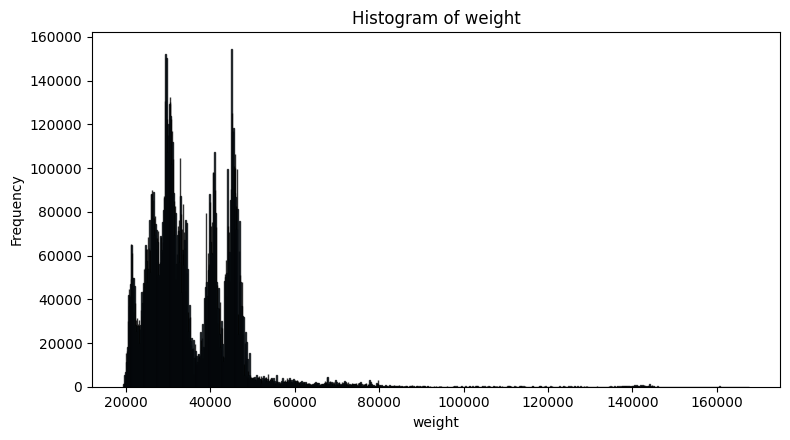

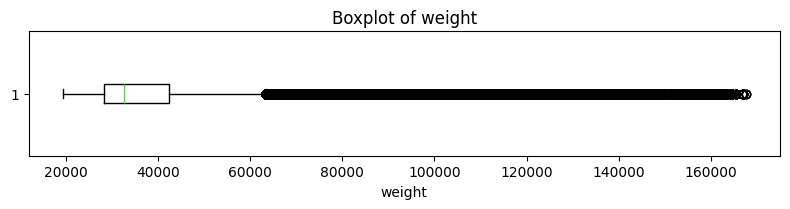


Numeric variable: coview_seconds


,count,mean,std,min,25%,median,75%,max,skewness,missing_values
0,15000000.0,4.8899,10.4755,0.0,0.0,0.0,4.0,457.0,3.3737,0


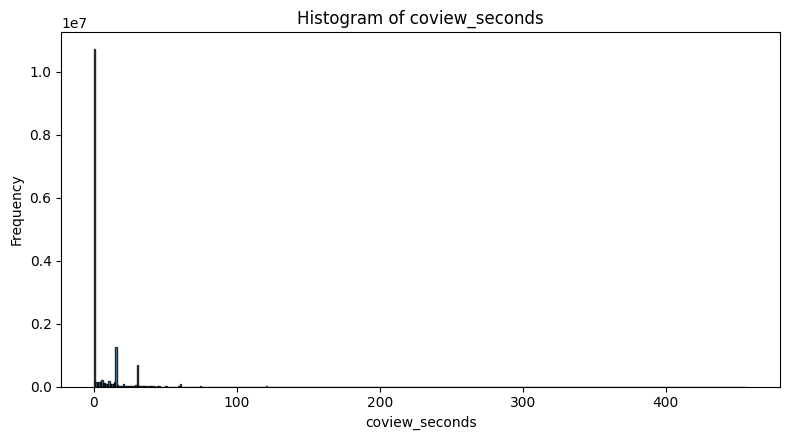

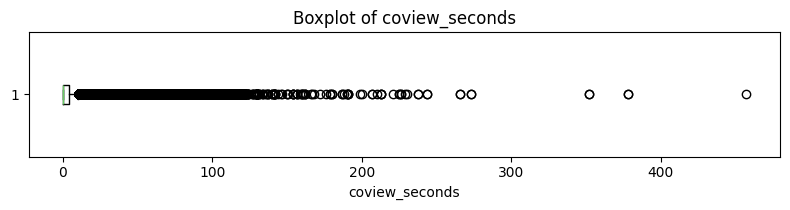


Numeric variable: attention_rate


,count,mean,std,min,25%,median,75%,max,skewness,missing_values
0,14999524.0,0.3519,0.3947,0.0,0.0,0.1333,0.75,1.0,0.6053,476


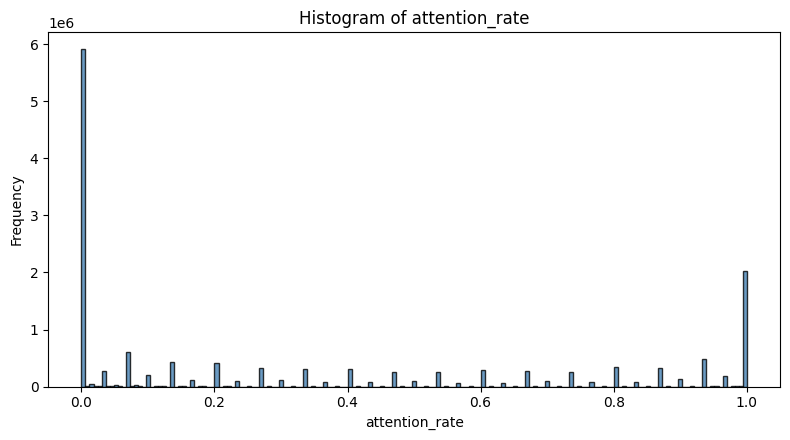

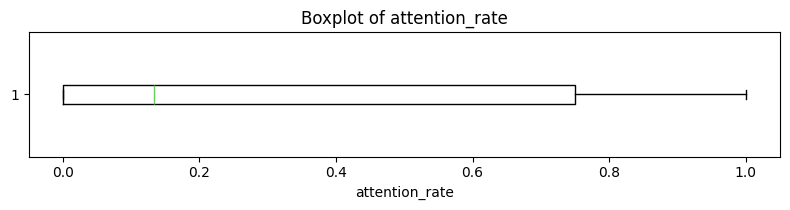


Numeric variable: visible_rate


,count,mean,std,min,25%,median,75%,max,skewness,missing_values
0,14999524.0,0.6613,0.424,0.0,0.1667,1.0,1.0,1.0,-0.6656,476


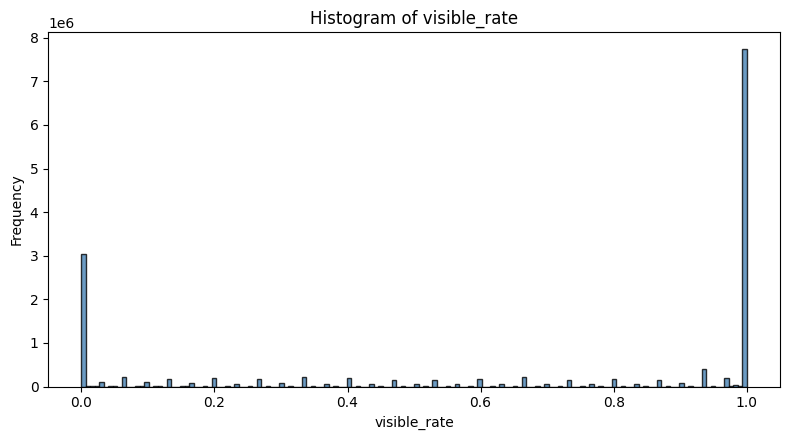

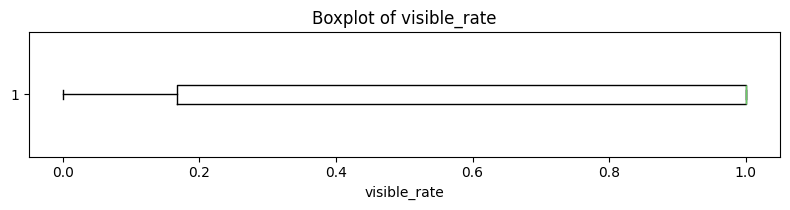


Numeric variable: attention_given_visible


,count,mean,std,min,25%,median,75%,max,skewness,missing_values
0,11949887.0,0.5178,0.4106,0.0,0.0357,0.5333,1.0,1.0,-0.0786,3050113


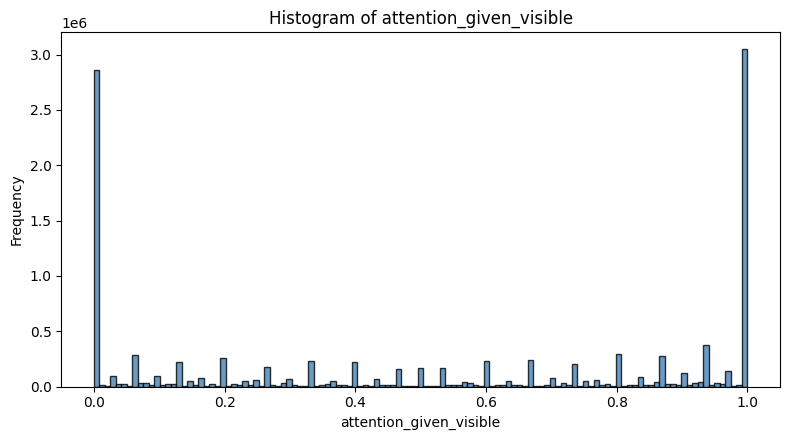

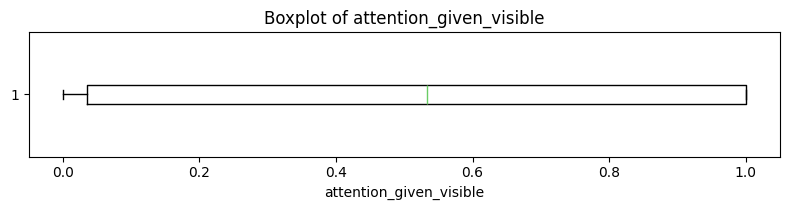


Numeric variable: hour_of_day


,count,mean,std,min,25%,median,75%,max,skewness,missing_values
0,15000000.0,15.2017,5.7432,0.0,11.0,17.0,20.0,23.0,-0.816,0


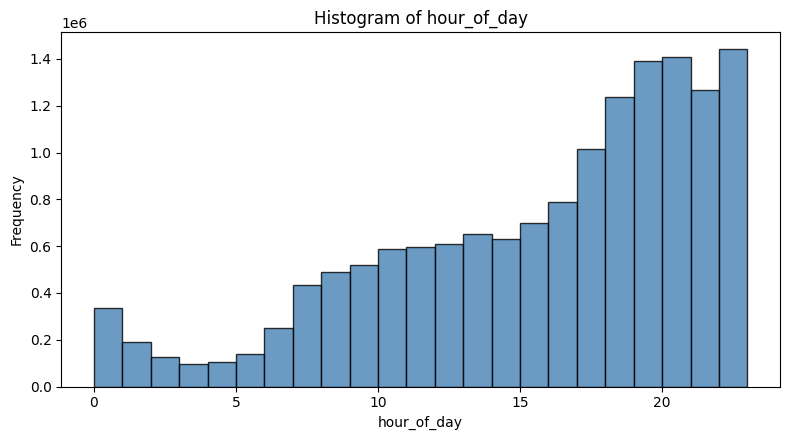

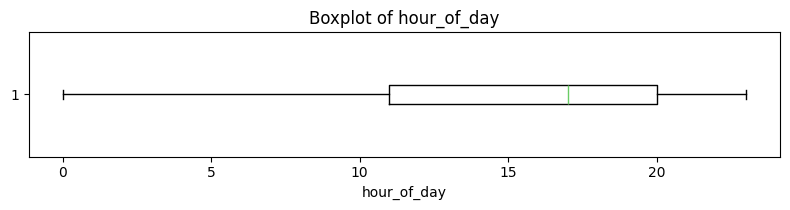


Categorical variable: industry
Unique values (excluding missing): 21
Top 10 levels by frequency:


,count
industry,
Entertainment / Media / Leisure,3526557
Health,2256288
Legal / Financial,1581151
Retail,1432103
Consumer Products,924166
Restaurants,896391
Food / Beverages,876142
Automotive / Vehicles,820995
Services,594153


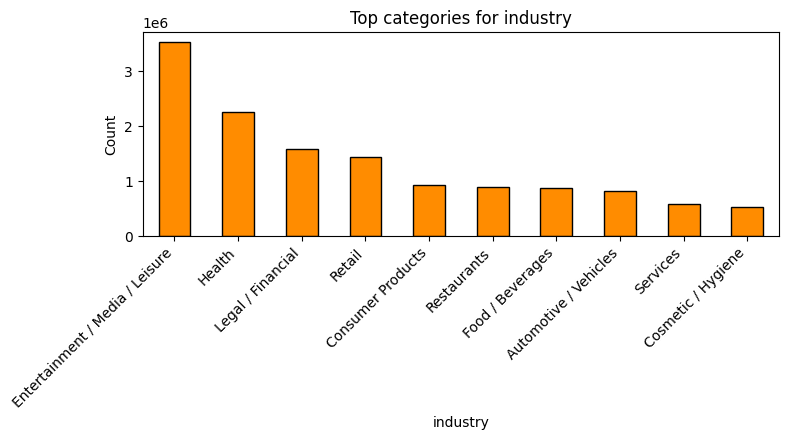


Categorical variable: sub_industry
Unique values (excluding missing): 378
Top 10 levels by frequency:


,count
sub_industry,
Entertainment / Media / Leisure - Television Program,2532971
Health - Prescription,804032
Automotive / Vehicles - Car Dealer,504946
Restaurants - Fast Food,397670
Legal / Financial - Insurance Various,374042
Retail - Home / Kitchen / Bathroom Stores,339959
Retail - Department Stores,329633
Telecommunications - Mobile Phone Network Provider,289743
Restaurants - Fast Food / Fast Casual,255261


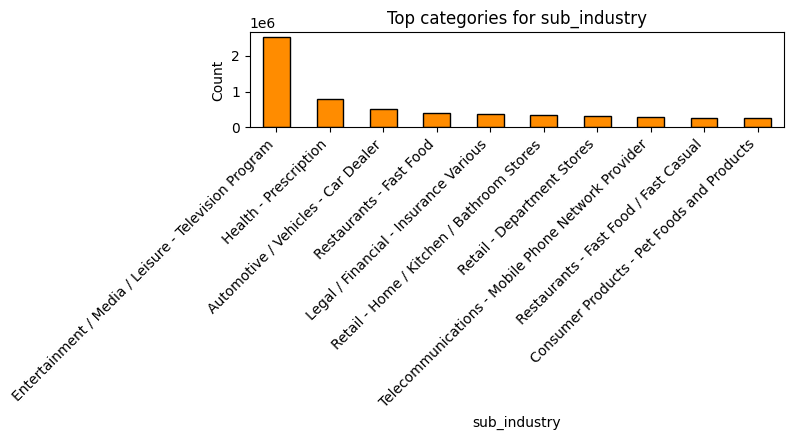


Categorical variable: brand_name
Unique values (excluding missing): 12923
Top 10 levels by frequency:


,count
brand_name,
ABC,781000
CBS,642828
Burger King,215472
Allstate,206062
AT&T,140859
Amazon,129592
FOX,124730
Ashley HomeStore,111085
CNN,108457


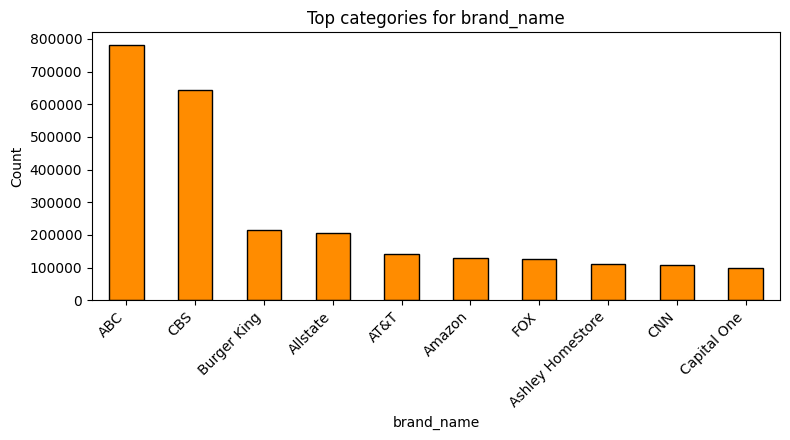


Categorical variable: product_name
Unique values (excluding missing): 24218
Top 10 levels by frequency:


,count
product_name,
Allstate,206062
AT&T,138317
Amazon,129509
Ashley HomeStore,111185
Amazon Prime,82483
Burger King - Various,70444
DUPIXENT,65586
Consumer Cellular,62305
AUSTEDO,58301


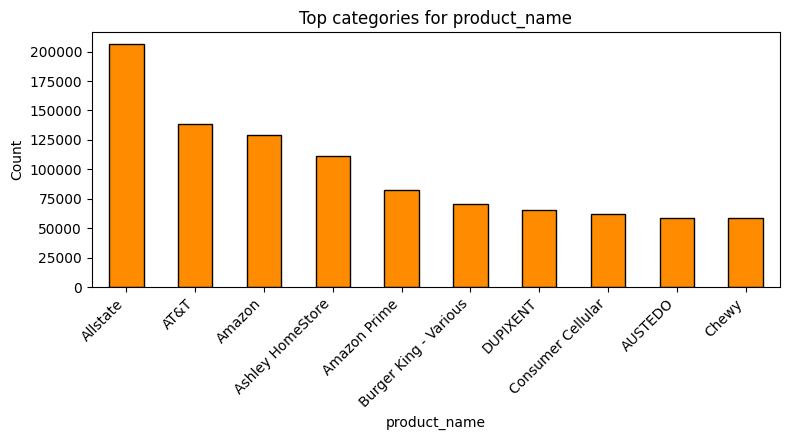


Categorical variable: source_type
Unique values (excluding missing): 2
Top 10 levels by frequency:


,count
source_type,
linear,14898048
ctv,101952


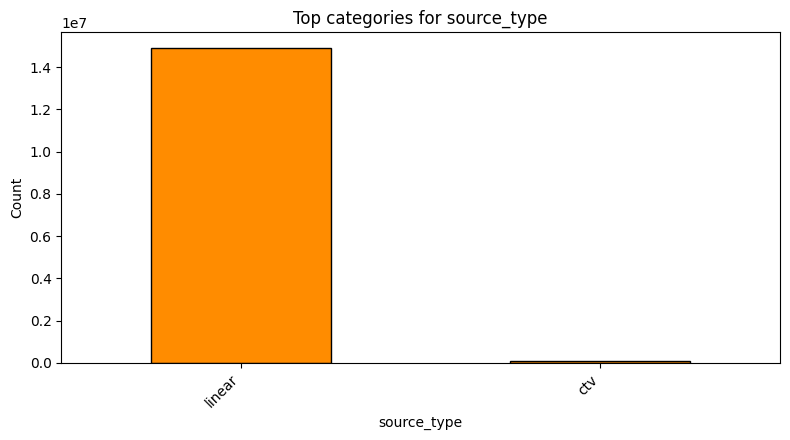


Categorical variable: source
Unique values (excluding missing): 210
Top 10 levels by frequency:


,count
source,
ABC,2512005
CBS,2199460
NBC,1342065
FOX,957747
FOX News,615868
CNN,458077
ESPN,429168
MSNBC,310676
ION,224446


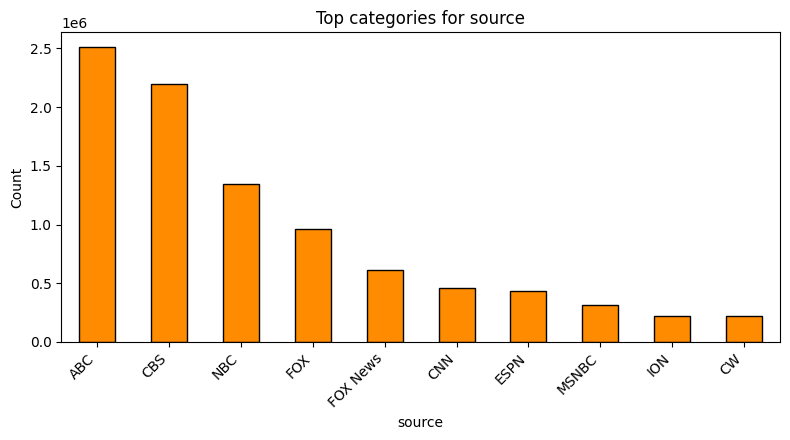


Categorical variable: source_category
Unique values (excluding missing): 17
Top 10 levels by frequency:


,count
source_category,
Cable,7379325
Broadcast,7227825
Other OTA,227716
Spanish Language,63182
dMVPD,38138
Hybrid SVOD/AVOD,25924
AVOD,19009
MVPD,7306
News,4826


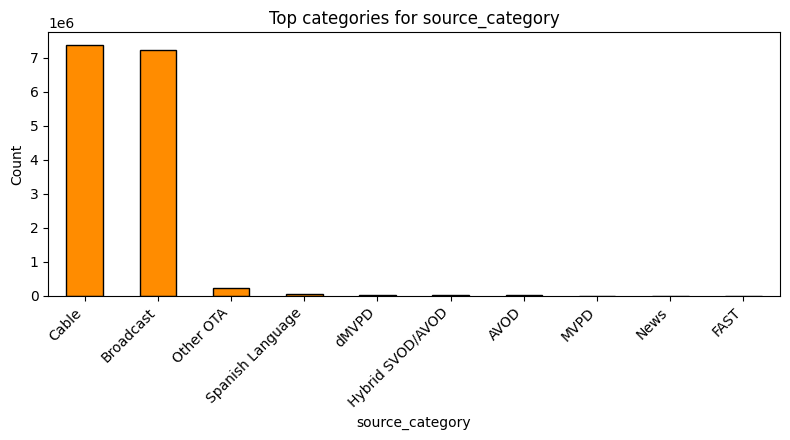


Categorical variable: program_name
Unique values (excluding missing): 14277
Top 10 levels by frequency:


,count
program_name,
NFL Football,476859
College Football,284798
ABC World News Tonight With David Muir,176099
NFL Playoff,169897
Jeopardy!,158663
Law & Order: Special Victims Unit,138806
Good Morning America,133853
The Price Is Right,131065
The Big Bang Theory,129703


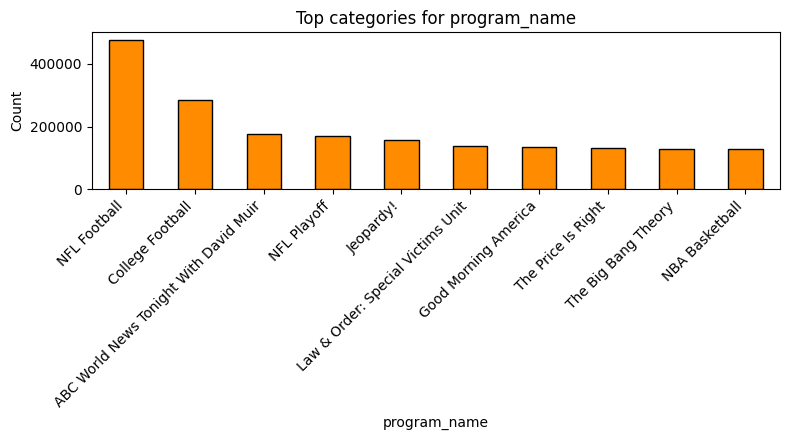


Categorical variable: daypart
Unique values (excluding missing): 11
Top 10 levels by frequency:


,count
daypart,
Daytime,4157036
Prime,3623545
Early Fringe,2681895
Early Morning,1009453
Early Access,814759
Morning,789423
Prime Access,698844
Late Night,504084
Overnight,438739


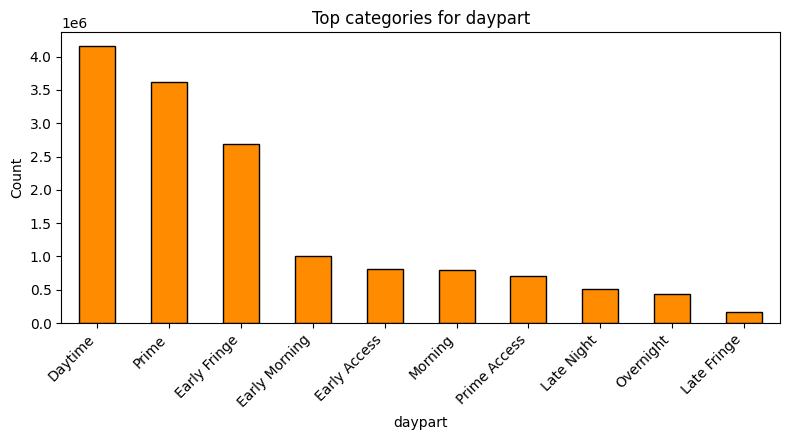


Categorical variable: viewing_start_time_local
Unique values (excluding missing): 6222862
Top 10 levels by frequency:


,count
viewing_start_time_local,
2026-02-08 19:01:19,491
2026-02-08 20:16:04,407
2026-02-08 20:33:33,380
2026-02-08 19:43:08,379
2026-02-08 21:28:36,369
2026-02-08 20:32:33,345
2026-02-08 21:07:48,333
2026-02-08 19:51:01,330
2026-02-08 19:55:21,319


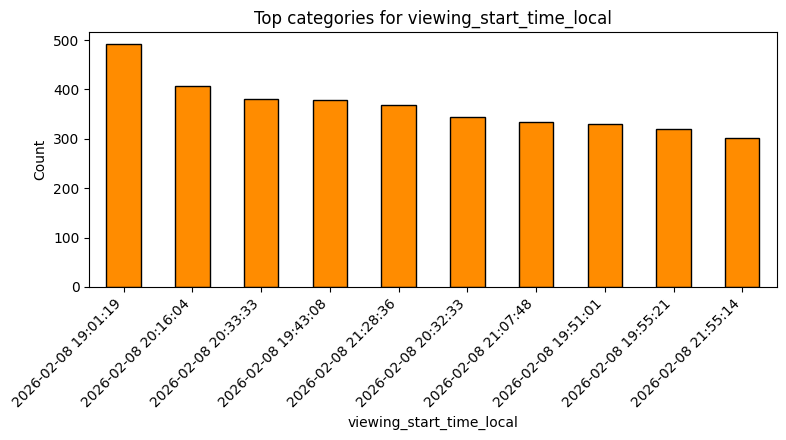


Categorical variable: viewing_end_time_local
Unique values (excluding missing): 6258526
Top 10 levels by frequency:


,count
viewing_end_time_local,
2026-02-08 19:01:48,456
2026-02-08 20:34:02,411
2026-02-08 19:43:37,398
2026-02-08 20:16:33,371
2026-02-08 21:08:47,358
2026-02-08 20:32:52,343
2026-02-08 21:29:35,319
2026-02-08 19:51:30,309
2026-02-08 21:55:43,307


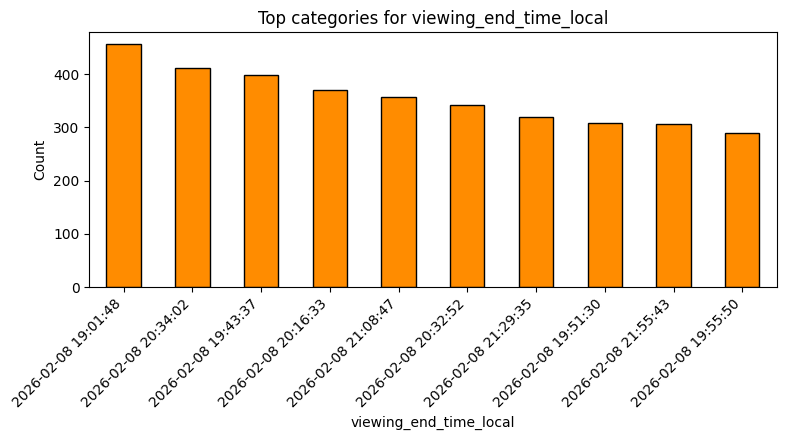


Categorical variable: gender
Unique values (excluding missing): 2
Top 10 levels by frequency:


,count
gender,
F,8040763
M,6959237


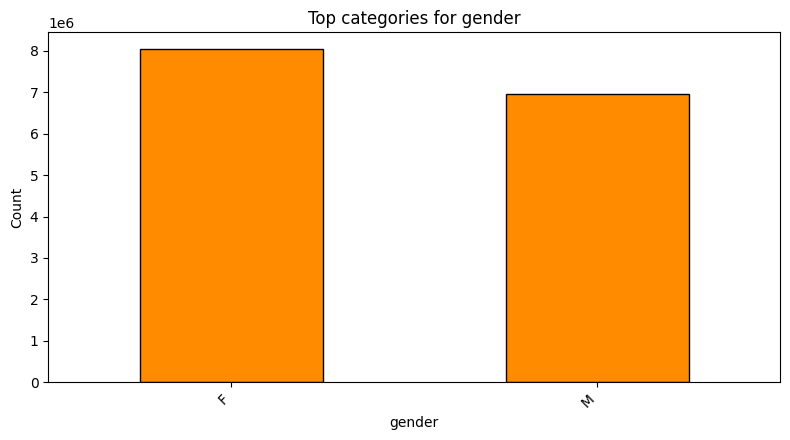


Categorical variable: content_genres
Unique values (excluding missing): 10604
Top 10 levels by frequency:


,count
content_genres,
"[""local"",""newscast""]",944543
"[""Sports Event"",""football"",""pro"",""regular season""]",438035
"[""sitcom"",""comedy""]",435762
"[""newscast""]",424820
[],310699
"[""current affairs"",""newscast"",""public affairs""]",219456
"[""Sports Event"",""college"",""football""]",177288
"[""Sports Event"",""football"",""playoffs"",""pro""]",153361
"[""current affairs"",""politics"",""talk""]",138005


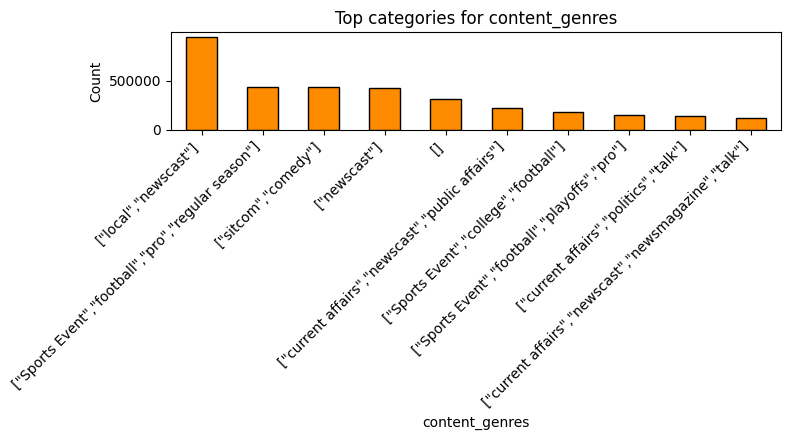


Categorical variable: series_movie_ind
Unique values (excluding missing): 4
Top 10 levels by frequency:


,count
series_movie_ind,
episode,11806455
series,1876200
movie,1170823
other,146522


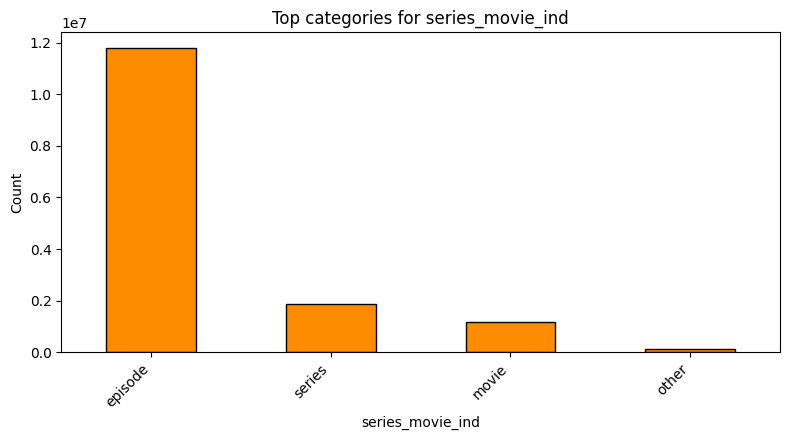


Categorical variable: is_weekend
Unique values (excluding missing): 2
Top 10 levels by frequency:


,count
is_weekend,
False,10673083
True,4326917


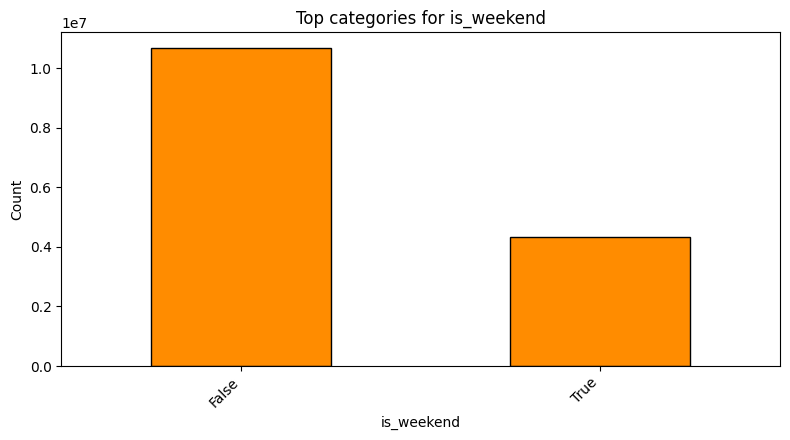

Skipping categorical column 'age_group' due to processing error: Cannot setitem on a Categorical with a new category (<Missing>), set the categories first

Final variable summary table:


,variable_name,type,missing_count,unique_count,skewness,flag
0,brand_name,categorical,476,12923,NaN,high cardinality
1,content_genres,categorical,0,10604,NaN,high cardinality
2,daypart,categorical,0,11,NaN,balanced
3,gender,categorical,0,2,NaN,balanced
4,industry,categorical,487,21,NaN,balanced
5,is_weekend,categorical,0,2,NaN,balanced
6,product_name,categorical,476,24218,NaN,high cardinality
7,program_name,categorical,40,14277,NaN,high cardinality
8,series_movie_ind,categorical,0,4,NaN,balanced
9,source,categorical,0,210,NaN,high cardinality


In [12]:
# Post-transformation distribution checks
# Uses the final in-memory dataframe when available instead of recreating prior steps.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def detect_main_dataframe(namespace):
    """Pick the most likely final modeling/analysis dataframe from the current namespace."""
    candidates = []

    for order, (name, obj) in enumerate(namespace.items()):
        if not isinstance(obj, pd.DataFrame):
            continue
        if obj.empty:
            continue

        lower_name = name.lower()
        score = float(order) / 1000.0

        if "train" in lower_name:
            score += 50
        if "model" in lower_name:
            score += 30
        if "final" in lower_name:
            score += 25
        if "clean" in lower_name:
            score += 20
        if "analysis" in lower_name:
            score += 15
        if "feature" in lower_name:
            score += 15
        if "master" in lower_name:
            score += 5
        if "test" in lower_name:
            score -= 20
        if "valid" in lower_name or "val" in lower_name:
            score -= 10

        score += min(len(obj.columns), 200) / 100.0
        score += min(len(obj), 100000) / 1000000.0

        candidates.append(
            {
                "name": name,
                "df": obj,
                "score": score,
                "rows": len(obj),
                "cols": len(obj.columns),
            }
        )

    if not candidates:
        raise ValueError(
            "No populated pandas DataFrame objects were found in the current notebook namespace."
        )

    ranked = pd.DataFrame(candidates).sort_values(
        ["score", "rows", "cols"], ascending=False
    )
    selected = ranked.iloc[0]

    print(
        f"Selected dataframe: {selected['name']} | rows={selected['rows']:,} | columns={selected['cols']:,}"
    )

    if len(ranked) > 1:
        print("Top dataframe candidates considered:")
        display(
            ranked[["name", "rows", "cols", "score"]].head(5).reset_index(drop=True)
        )

    return selected["name"], selected["df"]


selected_df_name, distribution_df = detect_main_dataframe(globals())

# Exclude identifier, raw-duration, and provenance fields from this end-of-notebook review.
excluded_columns_normalized = {
    "age",
    "hh_id",
    "demo_id",
    "attention_seconds",
    "visible_seconds",
    "duration",
    "contextual_match",
    "source_file",
    "source_month",
    "day_name",
}

# Common spelling variants requested for exclusion.
excluded_columns_normalized.update(
    {
        "vissible_seconds",
        "sorce_file",
    }
)


def normalize_column_name(column_name):
    return str(column_name).strip().lower()


all_numeric_columns = distribution_df.select_dtypes(
    include=[np.number]
).columns.tolist()
all_categorical_columns = distribution_df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

numeric_columns = [
    column
    for column in all_numeric_columns
    if normalize_column_name(column) not in excluded_columns_normalized
]
categorical_columns = [
    column
    for column in all_categorical_columns
    if normalize_column_name(column) not in excluded_columns_normalized
]

# Prefer age_group over age for this section whenever age_group is available.
age_group_column = next(
    (
        column
        for column in distribution_df.columns
        if normalize_column_name(column) == "age_group"
    ),
    None,
)
if age_group_column is not None and age_group_column not in categorical_columns:
    categorical_columns.append(age_group_column)

print(f"Numeric columns detected after exclusions: {len(numeric_columns)}")
print(f"Categorical columns detected after exclusions: {len(categorical_columns)}")
print(
    "Excluded columns from post-transformation checks:",
    sorted(excluded_columns_normalized),
)

distribution_summary_rows = []
numeric_diagnostics = []
categorical_diagnostics = []


for column in numeric_columns:
    try:
        series = pd.to_numeric(distribution_df[column], errors="coerce")
        non_missing = series.dropna()
        missing_count = int(series.isna().sum())
        unique_count = int(series.nunique(dropna=True))

        if non_missing.empty:
            print(
                f"Skipping numeric column '{column}' because it has no non-missing values."
            )
            distribution_summary_rows.append(
                {
                    "variable_name": column,
                    "type": "numeric",
                    "missing_count": missing_count,
                    "unique_count": unique_count,
                    "skewness": np.nan,
                    "flag": "sparse",
                }
            )
            continue

        desc = non_missing.describe(percentiles=[0.25, 0.5, 0.75])
        skewness = float(non_missing.skew()) if len(non_missing) > 2 else np.nan
        q1 = float(desc["25%"])
        q3 = float(desc["75%"])
        iqr = q3 - q1

        if iqr > 0:
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr
            outlier_count = int(
                ((non_missing < lower_bound) | (non_missing > upper_bound)).sum()
            )
        else:
            outlier_count = 0

        if pd.notna(skewness) and abs(skewness) > 1:
            flag = "skewed"
        elif missing_count > len(series) * 0.5:
            flag = "sparse"
        else:
            flag = "balanced"

        summary_stats_df = pd.DataFrame(
            [
                {
                    "count": float(desc["count"]),
                    "mean": float(desc["mean"]),
                    "std": float(desc["std"]) if pd.notna(desc["std"]) else np.nan,
                    "min": float(desc["min"]),
                    "25%": q1,
                    "median": float(desc["50%"]),
                    "75%": q3,
                    "max": float(desc["max"]),
                    "skewness": skewness,
                    "missing_values": missing_count,
                }
            ]
        )

        print(f"\nNumeric variable: {column}")
        display(summary_stats_df.round(4))

        plt.figure(figsize=(8, 4.5))
        plt.hist(
            non_missing, bins="auto", color="steelblue", edgecolor="black", alpha=0.8
        )
        plt.title(f"Histogram of {column}")
        plt.xlabel(column)
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(8, 2.2))
        plt.boxplot(non_missing, vert=False)
        plt.title(f"Boxplot of {column}")
        plt.xlabel(column)
        plt.tight_layout()
        plt.show()

        numeric_diagnostics.append(
            {
                "variable_name": column,
                "skewness": skewness,
                "outlier_count": outlier_count,
                "missing_count": missing_count,
                "unique_count": unique_count,
            }
        )

        distribution_summary_rows.append(
            {
                "variable_name": column,
                "type": "numeric",
                "missing_count": missing_count,
                "unique_count": unique_count,
                "skewness": skewness,
                "flag": flag,
            }
        )
    except Exception as exc:
        print(f"Skipping numeric column '{column}' due to processing error: {exc}")


for column in categorical_columns:
    try:
        series = distribution_df[column]
        missing_count = int(series.isna().sum())
        unique_count = int(series.nunique(dropna=True))
        counts = series.fillna("<Missing>").astype(str).value_counts().head(10)

        if unique_count > 100:
            flag = "high cardinality"
        elif missing_count > len(series) * 0.5:
            flag = "sparse"
        else:
            flag = "balanced"

        print(f"\nCategorical variable: {column}")
        print(f"Unique values (excluding missing): {unique_count}")
        print("Top 10 levels by frequency:")
        display(counts.rename("count").to_frame())

        plt.figure(figsize=(8, 4.5))
        counts.sort_values(ascending=False).plot(
            kind="bar", color="darkorange", edgecolor="black"
        )
        plt.title(f"Top categories for {column}")
        plt.xlabel(column)
        plt.ylabel("Count")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

        categorical_diagnostics.append(
            {
                "variable_name": column,
                "missing_count": missing_count,
                "unique_count": unique_count,
            }
        )

        distribution_summary_rows.append(
            {
                "variable_name": column,
                "type": "categorical",
                "missing_count": missing_count,
                "unique_count": unique_count,
                "skewness": np.nan,
                "flag": flag,
            }
        )
    except Exception as exc:
        print(f"Skipping categorical column '{column}' due to processing error: {exc}")


distribution_summary_df = pd.DataFrame(distribution_summary_rows)

print("\nFinal variable summary table:")
display(
    distribution_summary_df.sort_values(["type", "variable_name"]).reset_index(
        drop=True
    )
)


### Interpretation

The notes below summarize the main post-transformation distribution patterns, including skewness, outliers, high-cardinality categoricals, and possible data quality issues detected from the current working dataset.


In [13]:
# Concise interpretation based on the summary objects created above.

if "distribution_summary_df" not in globals() or distribution_summary_df.empty:
    print(
        "Distribution summary is unavailable. Run the previous distribution-check cell first."
    )
else:
    numeric_diag_df = (
        pd.DataFrame(numeric_diagnostics) if numeric_diagnostics else pd.DataFrame()
    )
    categorical_diag_df = (
        pd.DataFrame(categorical_diagnostics)
        if categorical_diagnostics
        else pd.DataFrame()
    )

    highly_skewed = []
    extreme_outliers = []
    high_cardinality = []
    sparse_variables = []
    low_variation = []

    if not numeric_diag_df.empty:
        highly_skewed = (
            numeric_diag_df.loc[numeric_diag_df["skewness"].abs() > 1, "variable_name"]
            .sort_values()
            .tolist()
        )
        extreme_outliers = (
            numeric_diag_df.loc[numeric_diag_df["outlier_count"] > 0, "variable_name"]
            .sort_values()
            .tolist()
        )

    if not categorical_diag_df.empty:
        high_cardinality = (
            categorical_diag_df.loc[
                categorical_diag_df["unique_count"] > 100, "variable_name"
            ]
            .sort_values()
            .tolist()
        )

    sparse_variables = (
        distribution_summary_df.loc[
            distribution_summary_df["missing_count"] > len(distribution_df) * 0.5,
            "variable_name",
        ]
        .sort_values()
        .tolist()
    )
    low_variation = (
        distribution_summary_df.loc[
            distribution_summary_df["unique_count"] <= 1, "variable_name"
        ]
        .sort_values()
        .tolist()
    )

    print("Post-transformation interpretation:")
    print(
        "- Highly skewed variables: "
        + (
            ", ".join(highly_skewed[:15])
            if highly_skewed
            else "none detected above the skewness threshold."
        )
    )
    print(
        "- Variables with extreme outliers by the IQR rule: "
        + (", ".join(extreme_outliers[:15]) if extreme_outliers else "none detected.")
    )
    print(
        "- High-cardinality categorical variables: "
        + (
            ", ".join(high_cardinality[:15])
            if high_cardinality
            else "none detected above 100 unique categories."
        )
    )

    quality_notes = []
    if sparse_variables:
        quality_notes.append("high missingness in " + ", ".join(sparse_variables[:15]))
    if low_variation:
        quality_notes.append("very low variation in " + ", ".join(low_variation[:15]))

    print(
        "- Potential data quality concerns: "
        + (
            "; ".join(quality_notes)
            if quality_notes
            else "no major missingness or low-variation issues were flagged by these checks."
        )
    )


Post-transformation interpretation:
- Highly skewed variables: coview_seconds, weight
- Variables with extreme outliers by the IQR rule: coview_seconds, weight
- High-cardinality categorical variables: brand_name, content_genres, product_name, program_name, source, sub_industry, viewing_end_time_local, viewing_start_time_local
- Potential data quality concerns: no major missingness or low-variation issues were flagged by these checks.


## Additional Transformations

This section appends the requested Box-Cox transformation for `duration` and log transformation for `coview_seconds` using the cleaned analysis dataframe created earlier in the notebook.


In [14]:
# Requested transformations appended at the end of the notebook.

from scipy import stats

if "cleaned_df" not in globals():
    raise ValueError(
        "`cleaned_df` is not available. Run the earlier notebook cells first."
    )

if duration_col is None:
    raise ValueError("No duration column is available for the Box-Cox transformation.")

duration_series = pd.to_numeric(cleaned_df[duration_col], errors="coerce")
valid_duration_mask = duration_series > 0

cleaned_df["duration_boxcox"] = np.nan
if valid_duration_mask.any():
    cleaned_df.loc[valid_duration_mask, "duration_boxcox"], duration_boxcox_lambda = (
        stats.boxcox(duration_series.loc[valid_duration_mask])
    )
else:
    raise ValueError(
        "Box-Cox requires positive duration values, but none were available."
    )

if "coview_seconds" not in cleaned_df.columns:
    raise ValueError(
        "`coview_seconds` is not available for the requested log transformation."
    )

coview_series = pd.to_numeric(cleaned_df["coview_seconds"], errors="coerce")
valid_coview_mask = coview_series >= 0

cleaned_df["log_coview_seconds"] = np.nan
cleaned_df.loc[valid_coview_mask, "log_coview_seconds"] = np.log1p(
    coview_series.loc[valid_coview_mask]
)

transformation_summary = pd.DataFrame(
    {
        "metric": [duration_col, "coview_seconds"],
        "transformed_column": ["duration_boxcox", "log_coview_seconds"],
        "valid_input_rows": [
            int(valid_duration_mask.sum()),
            int(valid_coview_mask.sum()),
        ],
        "lambda": [duration_boxcox_lambda, np.nan],
    }
)

display(transformation_summary)
display(
    cleaned_df[
        [duration_col, "duration_boxcox", "coview_seconds", "log_coview_seconds"]
    ].head()
)


,metric,transformed_column,valid_input_rows,lambda
0,duration,duration_boxcox,14999524,-0.179136
1,coview_seconds,log_coview_seconds,15000000,NaN


,duration,duration_boxcox,coview_seconds,log_coview_seconds
0,30.0,2.546980,0,0.000000
1,30.0,2.546980,0,0.000000
2,15.0,2.145688,0,0.000000
3,120.0,3.214462,0,0.000000
4,30.0,2.546980,29,3.401197


In [15]:
# Extract the first non-'other' word from the genre field.

import re

genre_col = next(
    (c for c in ["content_genres", "genre", "genres"] if c in cleaned_df.columns),
    None,
)

if genre_col is None:
    raise ValueError(
        "No genre column was found. Expected one of: content_genres, genre, genres."
    )


def extract_primary_genre(value):
    if pd.isna(value):
        return np.nan

    tokens = re.findall(r"[A-Za-z]+(?:['-][A-Za-z]+)?", str(value))
    for token in tokens:
        if token.lower() != "other":
            return token.title()

    return np.nan


cleaned_df["primary_genre"] = cleaned_df[genre_col].apply(extract_primary_genre)

print(f"Genre source column: {genre_col}")
print(f"Primary genre populated for {cleaned_df['primary_genre'].notna().sum():,} rows")
display(cleaned_df[[genre_col, "primary_genre"]].head(10))


Genre source column: content_genres
Primary genre populated for 14,637,931 rows


,content_genres,primary_genre
0,"[""other"",""romance""]",Romance
1,"[""christmas"",""drama""]",Christmas
2,"[""magic"",""entertainment"",""drama"",""sequel"",""family"",""action/adventure"",""adaptation"",""fantasy""]",Magic
3,"[""magic"",""entertainment"",""drama"",""sequel"",""family"",""action/adventure"",""adaptation"",""fantasy""]",Magic
4,"[""other"",""romance""]",Romance
5,"[""interview"",""local"",""newscast"",""talk""]",Interview
6,"[""christmas"",""comedy"",""romance""]",Christmas
7,"[""filmed on location"",""suspense/thriller"",""action/adventure"",""drama""]",Filmed
8,"[""local"",""newscast""]",Local
9,"[""current affairs"",""newscast"",""public affairs""]",Current


In [16]:
cleaned_df.head()


,hh_id,demo_id,industry,sub_industry,brand_name,product_name,duration,source_type,source,source_category,program_name,daypart,viewing_start_time_local,viewing_end_time_local,age,gender,weight,visible_seconds,attention_seconds,coview_seconds,content_genres,series_movie_ind,source_file,source_month,attention_rate,visible_rate,attention_given_visible,day_name,is_weekend,hour_of_day,contextual_match,age_group,duration_boxcox,log_coview_seconds,primary_genre
0,c83be26fd8fc080094b2bfb0bfbd1e9b,3c9aaacd4b9332c143c14a2b17522eda,Entertainment / Media / Leisure,Entertainment / Media / Leisure - Television Program,Hallmark Channel,Hallmark Channel - Holiday Touchdown: A Chiefs Love Story,30.0,ctv,Frndly TV,dMVPD,A '90s Christmas,Late Fringe,2025-01-01 23:44:55,2025-01-01 23:45:24,14.0,F,31499.917510,0,0,0,"[""other"",""romance""]",movie,weighted_data_2025_01.csv,2025-01,0.000000,0.000000,NaN,Wednesday,False,23,0,5-17,2.546980,0.000000,Romance
1,907f05497e600cf4cf6a78fba2f2b5e1,25cadd222ff068381f85a49e5136c100,Retail,Retail - Home / Kitchen / Bathroom Stores,Rooms To Go,Rooms To Go,30.0,ctv,Philo,dMVPD,Christmas at the Drive-In,Prime,2025-01-01 20:30:05,2025-01-01 20:30:33,57.0,M,28054.663036,29,28,0,"[""christmas"",""drama""]",movie,weighted_data_2025_01.csv,2025-01,0.933333,0.966667,0.965517,Wednesday,False,20,1,55-64,2.546980,0.000000,Christmas
2,50d4913cd0340ec61fd1c77f4c65b0aa,8b53b206ddec19488e6ae2527333b58a,Services,Services - Cleaning,Homeaglow,Homeaglow,15.0,ctv,Sling TV,dMVPD,Harry Potter and the Half-Blood Prince,Daytime,2025-01-01 13:23:27,2025-01-01 13:23:41,48.0,F,19726.479272,15,14,0,"[""magic"",""entertainment"",""drama"",""sequel"",""family"",""action/adventure"",""adaptation"",""fantasy""]",movie,weighted_data_2025_01.csv,2025-01,0.933333,1.000000,0.933333,Wednesday,False,13,0,45-54,2.145688,0.000000,Magic
3,50d4913cd0340ec61fd1c77f4c65b0aa,8b53b206ddec19488e6ae2527333b58a,Government / Organizations,Government / Organizations - Charities,ASPCA,ASPCA,120.0,ctv,Sling TV,dMVPD,Harry Potter and the Half-Blood Prince,Daytime,2025-01-01 13:36:25,2025-01-01 13:38:24,48.0,F,19726.479272,118,48,0,"[""magic"",""entertainment"",""drama"",""sequel"",""family"",""action/adventure"",""adaptation"",""fantasy""]",movie,weighted_data_2025_01.csv,2025-01,0.400000,0.983333,0.406780,Wednesday,False,13,0,45-54,3.214462,0.000000,Magic
4,29deacf9ab992f46020b26cb99d2f505,74201cac3de71fdeb174103be0f51b3a,Government / Organizations,Government / Organizations - Public Information Message,U.S. Department of Health & Human Services,U.S. Department of Health & Human Services - Risk Less. Do More.,30.0,ctv,YouTube,AVOD,A '90s Christmas,Daytime,2025-01-01 11:50:43,2025-01-01 11:51:11,51.0,F,28091.281723,29,22,29,"[""other"",""romance""]",movie,weighted_data_2025_01.csv,2025-01,0.733333,0.966667,0.758621,Wednesday,False,11,0,45-54,2.546980,3.401197,Romance


In [17]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# -----------------------------
# 1. Define target
# -----------------------------
target = "attention_given_visible"

# -----------------------------
# 2. Select features
# -----------------------------
features = [
    "industry",
    "sub_industry",
    "brand_name",
    "product_name",
    "duration",
    "source_type",
    "source_category",
    "program_name",
    "daypart",
    "series_movie_ind",
    "source_file",
    "day_name",
    "is_weekend",
    "hour_of_day",
    "contextual_match",
    "age_group",
    "duration_boxcox",
    "log_coview_seconds",
    "primary_genre",
]

df = cleaned_df[features + [target]].dropna().copy()

# -----------------------------
# 3. SAMPLE DATA FIRST
# -----------------------------
sample_df = df.sample(n=100000, random_state=42)  # change 100000 as needed

# If you want percentage instead, use:
# sample_df = df.sample(frac=0.1, random_state=42)

# -----------------------------
# 4. Split X and y
# -----------------------------
X = sample_df[features]
y = sample_df[target]

# -----------------------------
# 5. Identify column types
# -----------------------------
cat_cols = [
    "industry",
    "sub_industry",
    "brand_name",
    "product_name",
    "source_type",
    "source_category",
    "program_name",
    "daypart",
    "series_movie_ind",
    "source_file",
    "day_name",
    "age_group",
    "primary_genre",
]

# -----------------------------
# 6. One-hot encoding
# -----------------------------
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# -----------------------------
# 7. Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# -----------------------------
# 8. Train model
# -----------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# -----------------------------
# 9. Predictions
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# 10. Evaluation
# -----------------------------
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Sample size used: {len(sample_df):,}")
print(f"Number of encoded features: {X_encoded.shape[1]:,}")
print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")


Sample size used: 100,000
Number of encoded features: 19,990
R²: -0.1292
RMSE: 0.4361


In [18]:
coef_df = pd.DataFrame(
    {"feature": X_train.columns, "coefficient": model.coef_}
).sort_values(by="coefficient", ascending=False)

coef_df.head(20)


,feature,coefficient
17886,program_name_Reality Check with Ross Coulthart,2.182301
18015,program_name_Saturday Today Extra,1.753206
9197,product_name_Flex Seal - Various,1.744889
17373,program_name_NFL Slimetime Presents: Nickelodeon's Game Changers,1.717643
18536,program_name_The Big Bake,1.504295
16435,program_name_Joker,1.499548
18231,program_name_Special Olympics World Winter Games Turin 2025,1.493091
18820,program_name_The Lead: Weekend,1.420366
14496,program_name_Best of Localish,1.419931
16910,program_name_Man of Steel,1.380972


=== NUMERIC CORRELATIONS WITH ATTENTION METRICS ===

Correlations with attention metrics:


,attention_rate,attention_given_visible
visible_rate,0.590,0.098
log_coview_seconds,0.167,0.004
coview_seconds,0.166,0.018
age,0.087,0.077
hour_of_day,0.055,0.063
contextual_match,0.010,0.015
is_weekend,-0.000,0.005
duration,-0.041,-0.015
duration_boxcox,-0.043,-0.015


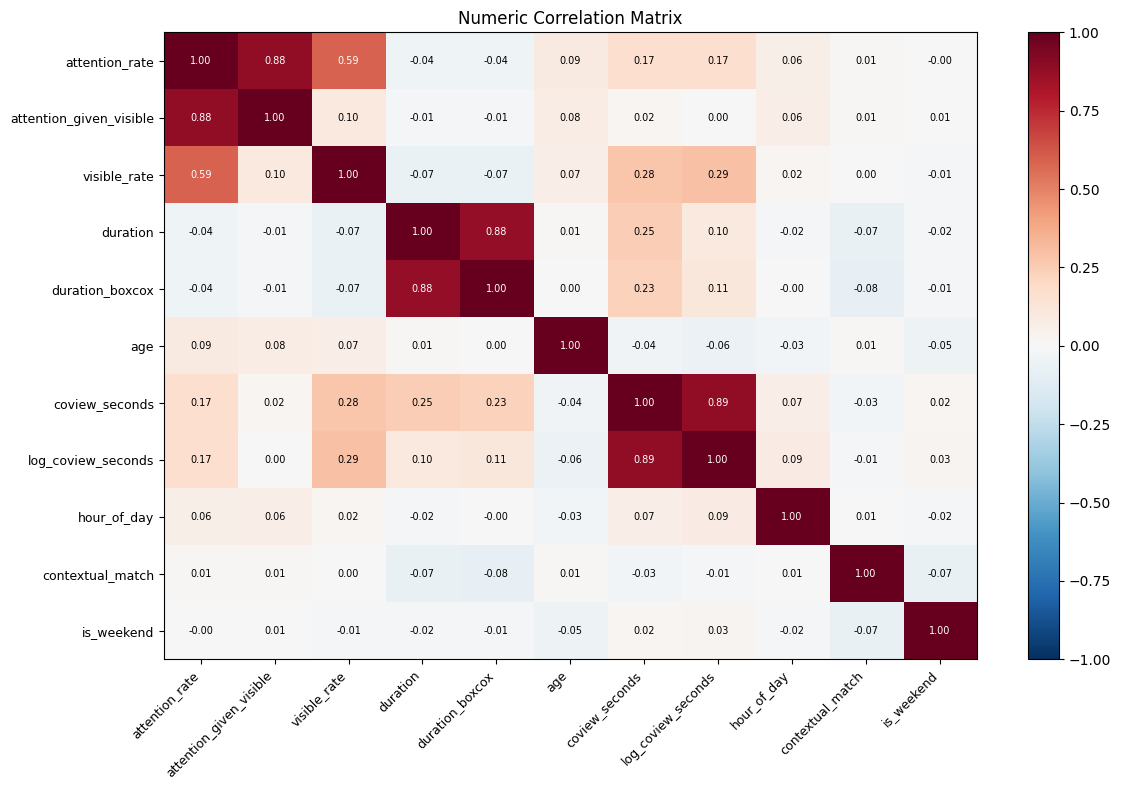


=== PIVOT: DAYPART × SOURCE_TYPE → attention_rate ===



source_type,ctv,linear,gap (linear-ctv)
daypart,,,
Early Morning,0.2137,0.3259,0.1122
Late News,0.2860,0.3887,0.1027
Early Access,0.2898,0.3757,0.0859
Daytime,0.2611,0.3363,0.0752
Early Fringe,0.2816,0.3567,0.0751
Prime,0.3087,0.3795,0.0708
Prime Access,0.3175,0.3868,0.0693
Overnight,0.2517,0.2936,0.0419
Late Fringe,0.3323,0.3426,0.0103


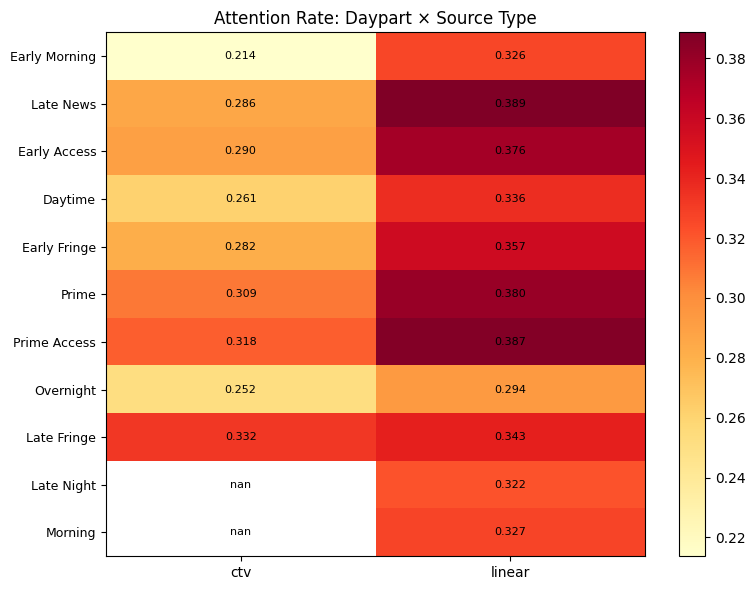


=== PIVOT: DAYPART × CONTEXTUAL_MATCH → attention_rate ===



,No Match,Match,lift (pp)
daypart,,,
Prime Access,0.3766,0.3976,2.10
Prime,0.3720,0.3864,1.44
Early Morning,0.3205,0.3317,1.12
Late Night,0.3173,0.3269,0.96
Morning,0.3248,0.3294,0.46
Daytime,0.3350,0.3372,0.22
Late News,0.3859,0.3847,-0.12
Early Fringe,0.3577,0.3543,-0.34
Early Access,0.3745,0.3710,-0.35



=== PIVOT: INDUSTRY × DAYPART → attention_rate ===



daypart,Daytime,Early Access,Early Fringe,Late News,Overnight,Prime,Prime Access
industry,,,,,,,
Automotive / Vehicles,0.3296,0.3616,0.3477,0.3798,0.3014,0.3703,0.3769
Consumer Products,0.3381,0.3763,0.3556,0.3601,0.2953,0.3819,0.3913
Cosmetic / Hygiene,0.3350,0.3768,0.3526,0.3745,0.2870,0.3822,0.3856
Entertainment / Media / Leisure,0.3486,0.3848,0.3703,0.3887,0.2977,0.3976,0.4040
Food / Beverages,0.3439,0.3864,0.3594,0.3910,0.2927,0.3766,0.3827
Health,0.3228,0.3658,0.3518,0.3681,0.2879,0.3603,0.3657
Legal / Financial,0.3286,0.3688,0.3538,0.3934,0.3000,0.3745,0.3759
Restaurants,0.3386,0.3712,0.3558,0.3960,0.2823,0.3728,0.3750
Retail,0.3339,0.3735,0.3562,0.3890,0.2935,0.3749,0.3841


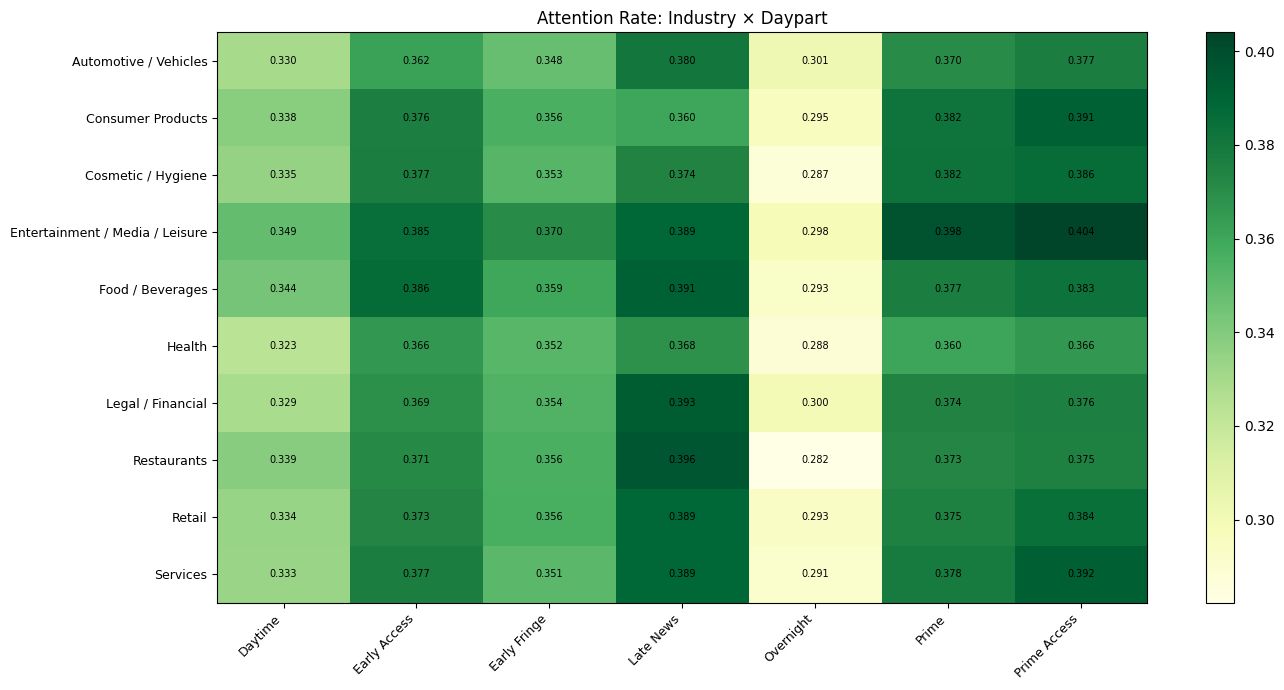


=== PIVOT: AGE_GROUP × SOURCE_TYPE → attention_rate ===



source_type,ctv,linear,gap (linear-ctv)
age_group,,,
5-17,0.2094,0.2529,0.0435
18-24,0.1381,0.2721,0.1340
25-34,0.2647,0.3011,0.0364
35-44,0.2913,0.3021,0.0108
45-54,0.2473,0.3279,0.0806
55-64,0.2792,0.3558,0.0766
65-80,0.2956,0.3811,0.0855



=== PIVOT: AGE_GROUP × CONTEXTUAL_MATCH → attention_rate ===



,No Match,Match,lift (pp)
age_group,,,
5-17,0.2461,0.2642,1.81
18-24,0.2678,0.2756,0.78
25-34,0.2979,0.3054,0.75
35-44,0.3011,0.3036,0.25
45-54,0.3243,0.3324,0.81
55-64,0.3527,0.3587,0.60
65-80,0.3769,0.3858,0.89



=== PIVOT: GENDER × DAYPART → attention_rate ===



daypart,Daytime,Early Access,Early Fringe,Early Morning,Late Fringe,Late News,Late Night,Morning,Overnight,Prime,Prime Access
gender,,,,,,,,,,,
F,0.3238,0.3593,0.3478,0.3154,0.3470,0.3875,0.3130,0.3215,0.2889,0.3740,0.3844
M,0.3501,0.3885,0.3659,0.3365,0.3374,0.3840,0.3316,0.3318,0.2977,0.3853,0.3884



=== PIVOT: PRIMARY_GENRE × SOURCE_TYPE → attention_rate ===



source_type,ctv,linear,gap (linear-ctv)
primary_genre,,,
Game,0.4115,0.3659,-0.0456
Newscast,0.3073,0.3429,0.0356
Interview,0.3371,0.3776,0.0405
Documentary,0.2970,0.3563,0.0593
Crime,0.2928,0.3522,0.0594
Drama,0.2924,0.3530,0.0606
Comedy,0.2961,0.3603,0.0642
Adaptation,0.3029,0.3703,0.0674
Entertainment,0.2978,0.3711,0.0733



All pivots exported to tableau_exports/


In [19]:
# ══════════════════════════════════════════════════════════════════
# CORRELATIONS & PIVOT TABLES — KEY INTERACTION ANALYSIS
# ══════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── 1. NUMERIC CORRELATION MATRIX ────────────────────────────────
print("=== NUMERIC CORRELATIONS WITH ATTENTION METRICS ===\n")

numeric_cols = [
    "attention_rate", "attention_given_visible", "visible_rate",
    "duration", "duration_boxcox", "age", "coview_seconds",
    "log_coview_seconds", "hour_of_day", "contextual_match", "is_weekend"
]
numeric_cols = [c for c in numeric_cols if c in cleaned_df.columns]

corr_df = cleaned_df[numeric_cols].copy()
if "is_weekend" in corr_df.columns:
    corr_df["is_weekend"] = corr_df["is_weekend"].astype(int)
corr_df = corr_df.apply(pd.to_numeric, errors="coerce")

corr_matrix = corr_df.corr().round(3)

# Correlations with the two target metrics
target_corrs = (
    corr_matrix[["attention_rate", "attention_given_visible"]]
    .drop(["attention_rate", "attention_given_visible"], errors="ignore")
    .sort_values("attention_rate", ascending=False)
)
print("Correlations with attention metrics:")
display(target_corrs)

# Heatmap — pure matplotlib, no seaborn
fig, ax = plt.subplots(figsize=(12, 8))
mat = corr_matrix.values
n = len(corr_matrix)
labels = corr_matrix.columns.tolist()

im = ax.imshow(mat, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(labels, fontsize=9)
for i in range(n):
    for j in range(n):
        val = mat[i, j]
        color = "white" if abs(val) > 0.5 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7, color=color)
ax.set_title("Numeric Correlation Matrix")
fig.tight_layout()
plt.show()

# ── 2. PIVOT: DAYPART × SOURCE_TYPE ──────────────────────────────
print("\n=== PIVOT: DAYPART × SOURCE_TYPE → attention_rate ===\n")

pivot_daypart_source = cleaned_df.pivot_table(
    values="attention_rate", index="daypart",
    columns="source_type", aggfunc="mean"
).round(4)
pivot_daypart_source["gap (linear-ctv)"] = (
    pivot_daypart_source.get("linear", 0) - pivot_daypart_source.get("ctv", 0)
).round(4)
pivot_daypart_source = pivot_daypart_source.sort_values("gap (linear-ctv)", ascending=False)
display(pivot_daypart_source)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
plot_data = pivot_daypart_source.drop(columns="gap (linear-ctv)", errors="ignore")
mat2 = plot_data.values
im2 = ax.imshow(mat2, cmap="YlOrRd", aspect="auto")
plt.colorbar(im2, ax=ax)
ax.set_xticks(range(len(plot_data.columns)))
ax.set_yticks(range(len(plot_data.index)))
ax.set_xticklabels(plot_data.columns, fontsize=10)
ax.set_yticklabels(plot_data.index, fontsize=9)
for i in range(len(plot_data.index)):
    for j in range(len(plot_data.columns)):
        ax.text(j, i, f"{mat2[i,j]:.3f}", ha="center", va="center", fontsize=8)
ax.set_title("Attention Rate: Daypart × Source Type")
fig.tight_layout()
plt.show()

# ── 3. PIVOT: DAYPART × CONTEXTUAL_MATCH ─────────────────────────
print("\n=== PIVOT: DAYPART × CONTEXTUAL_MATCH → attention_rate ===\n")

pivot_daypart_ctx = cleaned_df.pivot_table(
    values="attention_rate", index="daypart",
    columns="contextual_match", aggfunc="mean"
).round(4)
pivot_daypart_ctx.columns = ["No Match", "Match"]
pivot_daypart_ctx["lift (pp)"] = (
    (pivot_daypart_ctx["Match"] - pivot_daypart_ctx["No Match"]) * 100
).round(2)
pivot_daypart_ctx = pivot_daypart_ctx.sort_values("lift (pp)", ascending=False)
display(pivot_daypart_ctx)

# ── 4. PIVOT: INDUSTRY × DAYPART ─────────────────────────────────
print("\n=== PIVOT: INDUSTRY × DAYPART → attention_rate ===\n")

top_industries = cleaned_df["industry"].value_counts().head(10).index.tolist()
top_dayparts   = ["Prime Access", "Prime", "Late News", "Early Access",
                  "Early Fringe", "Daytime", "Overnight"]

pivot_ind_day = cleaned_df[
    cleaned_df["industry"].isin(top_industries) &
    cleaned_df["daypart"].isin(top_dayparts)
].pivot_table(
    values="attention_rate", index="industry",
    columns="daypart", aggfunc="mean"
).round(4)
display(pivot_ind_day)

fig, ax = plt.subplots(figsize=(14, 7))
mat3 = pivot_ind_day.values
im3 = ax.imshow(mat3, cmap="YlGn", aspect="auto")
plt.colorbar(im3, ax=ax)
ax.set_xticks(range(len(pivot_ind_day.columns)))
ax.set_yticks(range(len(pivot_ind_day.index)))
ax.set_xticklabels(pivot_ind_day.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(pivot_ind_day.index, fontsize=9)
for i in range(len(pivot_ind_day.index)):
    for j in range(len(pivot_ind_day.columns)):
        val = mat3[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=7)
ax.set_title("Attention Rate: Industry × Daypart")
fig.tight_layout()
plt.show()

# ── 5. PIVOT: AGE_GROUP × SOURCE_TYPE ────────────────────────────
print("\n=== PIVOT: AGE_GROUP × SOURCE_TYPE → attention_rate ===\n")

pivot_age_source = cleaned_df.pivot_table(
    values="attention_rate", index="age_group",
    columns="source_type", aggfunc="mean", observed=True
).round(4)
pivot_age_source["gap (linear-ctv)"] = (
    pivot_age_source.get("linear", 0) - pivot_age_source.get("ctv", 0)
).round(4)
display(pivot_age_source)

# ── 6. PIVOT: AGE_GROUP × CONTEXTUAL_MATCH ───────────────────────
print("\n=== PIVOT: AGE_GROUP × CONTEXTUAL_MATCH → attention_rate ===\n")

pivot_age_ctx = cleaned_df.pivot_table(
    values="attention_rate", index="age_group",
    columns="contextual_match", aggfunc="mean", observed=True
).round(4)
pivot_age_ctx.columns = ["No Match", "Match"]
pivot_age_ctx["lift (pp)"] = (
    (pivot_age_ctx["Match"] - pivot_age_ctx["No Match"]) * 100
).round(2)
display(pivot_age_ctx)

# ── 7. PIVOT: GENDER × DAYPART ───────────────────────────────────
print("\n=== PIVOT: GENDER × DAYPART → attention_rate ===\n")

pivot_gender_day = cleaned_df.pivot_table(
    values="attention_rate", index="gender",
    columns="daypart", aggfunc="mean"
).round(4)
display(pivot_gender_day)

# ── 8. PIVOT: PRIMARY_GENRE × SOURCE_TYPE ────────────────────────
print("\n=== PIVOT: PRIMARY_GENRE × SOURCE_TYPE → attention_rate ===\n")

top_genres = cleaned_df["primary_genre"].value_counts().head(15).index.tolist()
pivot_genre_source = cleaned_df[
    cleaned_df["primary_genre"].isin(top_genres)
].pivot_table(
    values="attention_rate", index="primary_genre",
    columns="source_type", aggfunc="mean"
).round(4)
pivot_genre_source["gap (linear-ctv)"] = (
    pivot_genre_source.get("linear", 0) - pivot_genre_source.get("ctv", 0)
).round(4)
pivot_genre_source = pivot_genre_source.sort_values("gap (linear-ctv)")
display(pivot_genre_source)

# ── 9. EXPORT ALL PIVOTS ─────────────────────────────────────────
from pathlib import Path
export_dir = Path("/home/capstone/FT2026/TVision/tableau_exports")
export_dir.mkdir(exist_ok=True)

pivot_daypart_source.reset_index().to_csv(export_dir / "09_pivot_daypart_source_type.csv", index=False)
pivot_daypart_ctx.reset_index().to_csv(export_dir / "10_pivot_daypart_contextual_match.csv", index=False)
pivot_ind_day.reset_index().to_csv(export_dir / "11_pivot_industry_daypart.csv", index=False)
pivot_age_source.reset_index().to_csv(export_dir / "12_pivot_age_source_type.csv", index=False)
pivot_age_ctx.reset_index().to_csv(export_dir / "13_pivot_age_contextual_match.csv", index=False)
pivot_gender_day.reset_index().to_csv(export_dir / "14_pivot_gender_daypart.csv", index=False)
pivot_genre_source.reset_index().to_csv(export_dir / "15_pivot_genre_source_type.csv", index=False)

print("\nAll pivots exported to tableau_exports/")

=== PIVOT: DAYPART × SOURCE_TYPE → attention_rate ===



source_type,ctv,linear,gap (linear - ctv)
daypart,,,
Early Morning,0.2137,0.3259,0.1122
Late News,0.2860,0.3887,0.1027
Early Access,0.2898,0.3757,0.0859
Daytime,0.2611,0.3363,0.0752
Early Fringe,0.2816,0.3567,0.0751
Prime,0.3087,0.3795,0.0708
Prime Access,0.3175,0.3868,0.0693
Overnight,0.2517,0.2936,0.0419
Late Fringe,0.3323,0.3426,0.0103


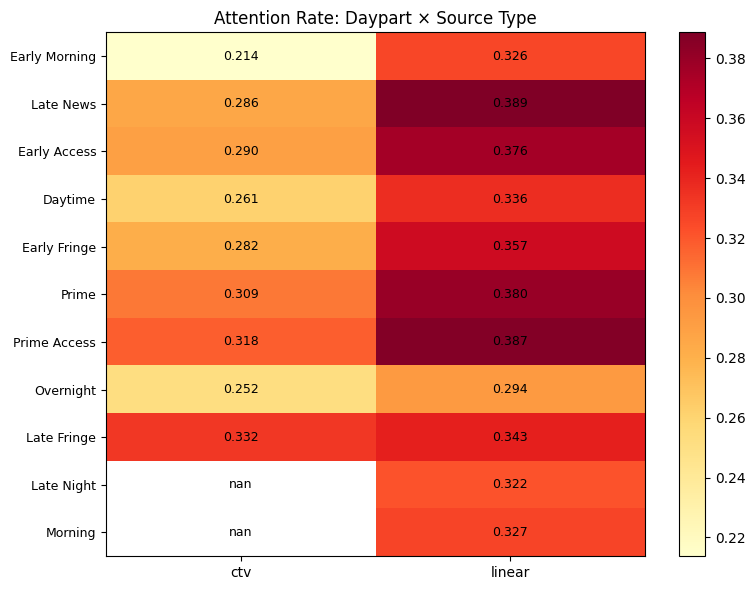

In [20]:
# ── 2. PIVOT: DAYPART × SOURCE_TYPE ──────────────────────────────
print("=== PIVOT: DAYPART × SOURCE_TYPE → attention_rate ===\n")

pivot_daypart_source = cleaned_df.pivot_table(
    values="attention_rate",
    index="daypart",
    columns="source_type",
    aggfunc="mean"
).round(4)

pivot_daypart_source["gap (linear - ctv)"] = (
    pivot_daypart_source.get("linear", 0) - pivot_daypart_source.get("ctv", 0)
).round(4)

pivot_daypart_source = pivot_daypart_source.sort_values("gap (linear - ctv)", ascending=False)
display(pivot_daypart_source)

# Heatmap — matplotlib only, no seaborn
plot_data = pivot_daypart_source.drop(columns="gap (linear - ctv)", errors="ignore")
mat = plot_data.values

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(mat, cmap="YlOrRd", aspect="auto")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(plot_data.columns)))
ax.set_yticks(range(len(plot_data.index)))
ax.set_xticklabels(plot_data.columns, fontsize=10)
ax.set_yticklabels(plot_data.index, fontsize=9)
for i in range(len(plot_data.index)):
    for j in range(len(plot_data.columns)):
        ax.text(j, i, f"{mat[i,j]:.3f}", ha="center", va="center", fontsize=9)
ax.set_title("Attention Rate: Daypart × Source Type")
fig.tight_layout()
plt.show()

In [21]:
# ── 3. PIVOT: DAYPART × CONTEXTUAL_MATCH ─────────────────────────
# Where does contextual match lift attention the most by time slot?
# Extends your XGBoost finding: Prime Access showed +2.1pp lift.

print("=== PIVOT: DAYPART × CONTEXTUAL_MATCH → attention_rate ===\n")

pivot_daypart_ctx = cleaned_df.pivot_table(
    values="attention_rate",
    index="daypart",
    columns="contextual_match",
    aggfunc="mean"
).round(4)

pivot_daypart_ctx.columns = ["No Match", "Match"]
pivot_daypart_ctx["lift (pp)"] = (
    (pivot_daypart_ctx["Match"] - pivot_daypart_ctx["No Match"]) * 100
).round(2)
pivot_daypart_ctx = pivot_daypart_ctx.sort_values("lift (pp)", ascending=False)
display(pivot_daypart_ctx)

=== PIVOT: DAYPART × CONTEXTUAL_MATCH → attention_rate ===



,No Match,Match,lift (pp)
daypart,,,
Prime Access,0.3766,0.3976,2.10
Prime,0.3720,0.3864,1.44
Early Morning,0.3205,0.3317,1.12
Late Night,0.3173,0.3269,0.96
Morning,0.3248,0.3294,0.46
Daytime,0.3350,0.3372,0.22
Late News,0.3859,0.3847,-0.12
Early Fringe,0.3577,0.3543,-0.34
Early Access,0.3745,0.3710,-0.35


=== PIVOT: INDUSTRY × DAYPART → attention_rate ===



daypart,Daytime,Early Access,Early Fringe,Late News,Overnight,Prime,Prime Access
industry,,,,,,,
Automotive / Vehicles,0.3296,0.3616,0.3477,0.3798,0.3014,0.3703,0.3769
Consumer Products,0.3381,0.3763,0.3556,0.3601,0.2953,0.3819,0.3913
Cosmetic / Hygiene,0.3350,0.3768,0.3526,0.3745,0.2870,0.3822,0.3856
Entertainment / Media / Leisure,0.3486,0.3848,0.3703,0.3887,0.2977,0.3976,0.4040
Food / Beverages,0.3439,0.3864,0.3594,0.3910,0.2927,0.3766,0.3827
Health,0.3228,0.3658,0.3518,0.3681,0.2879,0.3603,0.3657
Legal / Financial,0.3286,0.3688,0.3538,0.3934,0.3000,0.3745,0.3759
Restaurants,0.3386,0.3712,0.3558,0.3960,0.2823,0.3728,0.3750
Retail,0.3339,0.3735,0.3562,0.3890,0.2935,0.3749,0.3841


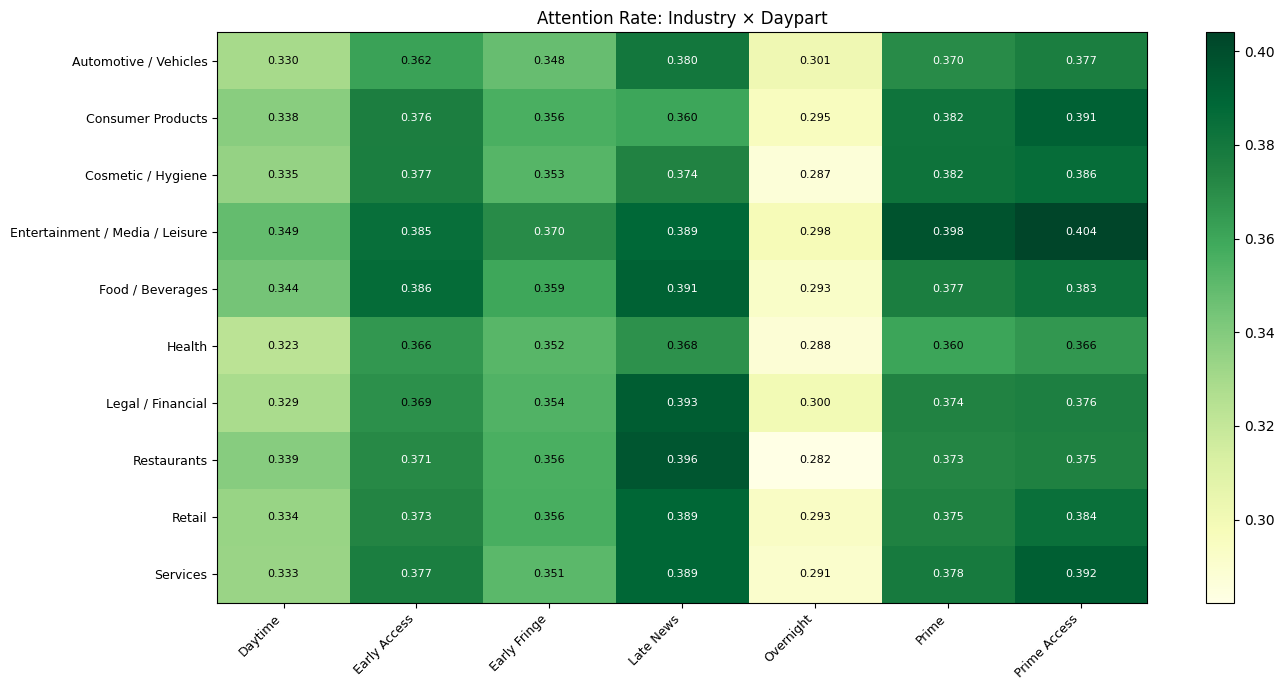

In [22]:
# ── 4. PIVOT: INDUSTRY × DAYPART ─────────────────────────────────
print("=== PIVOT: INDUSTRY × DAYPART → attention_rate ===\n")

top_industries = cleaned_df["industry"].value_counts().head(10).index.tolist()
top_dayparts = ["Prime Access", "Prime", "Late News", "Early Access",
                "Early Fringe", "Daytime", "Overnight"]

pivot_ind_day = cleaned_df[
    cleaned_df["industry"].isin(top_industries) &
    cleaned_df["daypart"].isin(top_dayparts)
].pivot_table(
    values="attention_rate",
    index="industry",
    columns="daypart",
    aggfunc="mean"
).round(4)

display(pivot_ind_day)

# Heatmap — matplotlib only
mat = pivot_ind_day.values
fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(mat, cmap="YlGn", aspect="auto")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(pivot_ind_day.columns)))
ax.set_yticks(range(len(pivot_ind_day.index)))
ax.set_xticklabels(pivot_ind_day.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(pivot_ind_day.index, fontsize=9)
for i in range(len(pivot_ind_day.index)):
    for j in range(len(pivot_ind_day.columns)):
        val = mat[i, j]
        if not np.isnan(val):
            color = "white" if val > 0.37 else "black"
            ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                    fontsize=8, color=color)
ax.set_title("Attention Rate: Industry × Daypart")
fig.tight_layout()
plt.show()

=== PIVOT: AGE_GROUP × SOURCE_TYPE → attention_rate ===



source_type,ctv,linear,gap (linear - ctv)
age_group,,,
5-17,0.2094,0.2529,0.0435
18-24,0.1381,0.2721,0.1340
25-34,0.2647,0.3011,0.0364
35-44,0.2913,0.3021,0.0108
45-54,0.2473,0.3279,0.0806
55-64,0.2792,0.3558,0.0766
65-80,0.2956,0.3811,0.0855


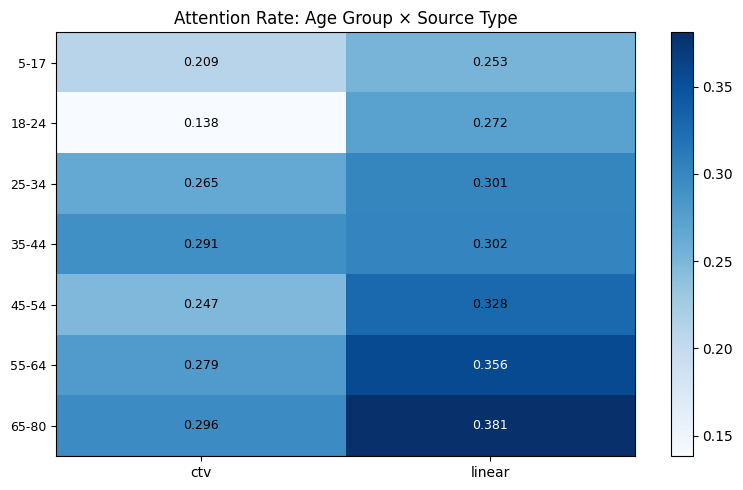

In [23]:
# ── 5. PIVOT: AGE_GROUP × SOURCE_TYPE ────────────────────────────
print("=== PIVOT: AGE_GROUP × SOURCE_TYPE → attention_rate ===\n")

pivot_age_source = cleaned_df.pivot_table(
    values="attention_rate",
    index="age_group",
    columns="source_type",
    aggfunc="mean",
    observed=True
).round(4)

pivot_age_source["gap (linear - ctv)"] = (
    pivot_age_source.get("linear", 0) - pivot_age_source.get("ctv", 0)
).round(4)

display(pivot_age_source)

# Heatmap — matplotlib only
plot_data = pivot_age_source.drop(columns="gap (linear - ctv)", errors="ignore")
mat = plot_data.values

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(mat, cmap="Blues", aspect="auto")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(plot_data.columns)))
ax.set_yticks(range(len(plot_data.index)))
ax.set_xticklabels(plot_data.columns, fontsize=10)
ax.set_yticklabels(plot_data.index.astype(str), fontsize=9)
for i in range(len(plot_data.index)):
    for j in range(len(plot_data.columns)):
        val = mat[i, j]
        if not np.isnan(val):
            color = "white" if val > 0.35 else "black"
            ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                    fontsize=9, color=color)
ax.set_title("Attention Rate: Age Group × Source Type")
fig.tight_layout()
plt.show()

In [24]:
# ── 6. PIVOT: AGE_GROUP × CONTEXTUAL_MATCH ───────────────────────
# Which age group responds most to contextual matching?
# Confirms your XGBoost finding: 35-54 showed +0.07pp lift.

print("=== PIVOT: AGE_GROUP × CONTEXTUAL_MATCH → attention_rate ===\n")

pivot_age_ctx = cleaned_df.pivot_table(
    values="attention_rate",
    index="age_group",
    columns="contextual_match",
    aggfunc="mean",
    observed=True
).round(4)

pivot_age_ctx.columns = ["No Match", "Match"]
pivot_age_ctx["lift (pp)"] = (
    (pivot_age_ctx["Match"] - pivot_age_ctx["No Match"]) * 100
).round(2)
display(pivot_age_ctx)

=== PIVOT: AGE_GROUP × CONTEXTUAL_MATCH → attention_rate ===



,No Match,Match,lift (pp)
age_group,,,
5-17,0.2461,0.2642,1.81
18-24,0.2678,0.2756,0.78
25-34,0.2979,0.3054,0.75
35-44,0.3011,0.3036,0.25
45-54,0.3243,0.3324,0.81
55-64,0.3527,0.3587,0.60
65-80,0.3769,0.3858,0.89


=== PIVOT: PRIMARY_GENRE × SOURCE_TYPE → attention_rate ===



source_type,ctv,linear,gap (linear - ctv)
primary_genre,,,
Game,0.4115,0.3659,-0.0456
Newscast,0.3073,0.3429,0.0356
Interview,0.3371,0.3776,0.0405
Documentary,0.2970,0.3563,0.0593
Crime,0.2928,0.3522,0.0594
Drama,0.2924,0.3530,0.0606
Comedy,0.2961,0.3603,0.0642
Adaptation,0.3029,0.3703,0.0674
Entertainment,0.2978,0.3711,0.0733


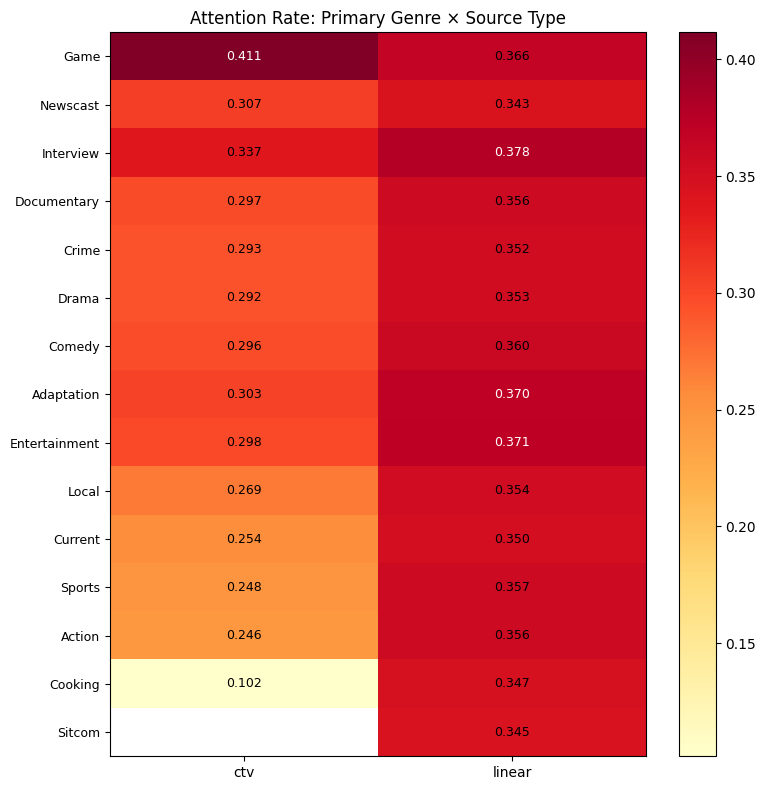

In [25]:
# ── 7. PIVOT: PRIMARY_GENRE × SOURCE_TYPE ────────────────────────
print("=== PIVOT: PRIMARY_GENRE × SOURCE_TYPE → attention_rate ===\n")

top_genres = cleaned_df["primary_genre"].value_counts().head(15).index.tolist()

pivot_genre_source = cleaned_df[
    cleaned_df["primary_genre"].isin(top_genres)
].pivot_table(
    values="attention_rate",
    index="primary_genre",
    columns="source_type",
    aggfunc="mean"
).round(4)

pivot_genre_source["gap (linear - ctv)"] = (
    pivot_genre_source.get("linear", 0) - pivot_genre_source.get("ctv", 0)
).round(4)

pivot_genre_source = pivot_genre_source.sort_values("gap (linear - ctv)")
display(pivot_genre_source)

# Heatmap — matplotlib only
plot_data = pivot_genre_source.drop(columns="gap (linear - ctv)", errors="ignore")
mat = plot_data.values

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(mat, cmap="YlOrRd", aspect="auto")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(plot_data.columns)))
ax.set_yticks(range(len(plot_data.index)))
ax.set_xticklabels(plot_data.columns, fontsize=10)
ax.set_yticklabels(plot_data.index.astype(str), fontsize=9)
for i in range(len(plot_data.index)):
    for j in range(len(plot_data.columns)):
        val = mat[i, j]
        if not np.isnan(val):
            color = "white" if val > 0.37 else "black"
            ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                    fontsize=9, color=color)
ax.set_title("Attention Rate: Primary Genre × Source Type")
fig.tight_layout()
plt.show()

=== PIVOT: GENDER × DAYPART → attention_rate ===



daypart,Daytime,Early Access,Early Fringe,Early Morning,Late Fringe,Late News,Late Night,Morning,Overnight,Prime,Prime Access
gender,,,,,,,,,,,
F,0.3238,0.3593,0.3478,0.3154,0.3470,0.3875,0.3130,0.3215,0.2889,0.3740,0.3844
M,0.3501,0.3885,0.3659,0.3365,0.3374,0.3840,0.3316,0.3318,0.2977,0.3853,0.3884


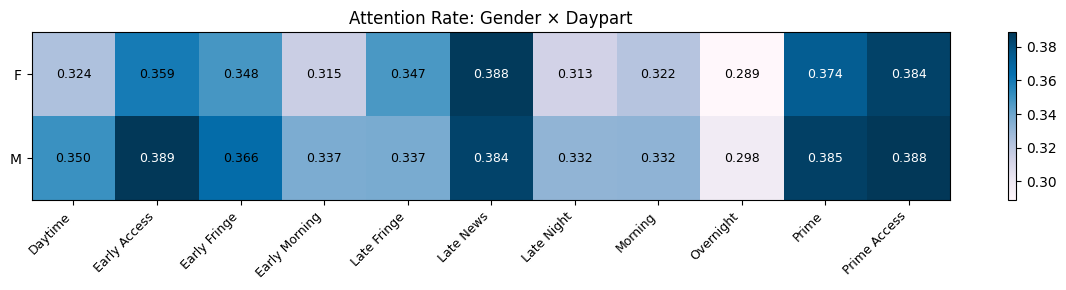

In [26]:
# ── 8. PIVOT: GENDER × DAYPART ───────────────────────────────────
print("=== PIVOT: GENDER × DAYPART → attention_rate ===\n")

pivot_gender_day = cleaned_df.pivot_table(
    values="attention_rate",
    index="gender",
    columns="daypart",
    aggfunc="mean"
).round(4)

display(pivot_gender_day)

# Heatmap — matplotlib only
mat = pivot_gender_day.values

fig, ax = plt.subplots(figsize=(12, 3))
im = ax.imshow(mat, cmap="PuBu", aspect="auto")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(pivot_gender_day.columns)))
ax.set_yticks(range(len(pivot_gender_day.index)))
ax.set_xticklabels(pivot_gender_day.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(pivot_gender_day.index.astype(str), fontsize=10)
for i in range(len(pivot_gender_day.index)):
    for j in range(len(pivot_gender_day.columns)):
        val = mat[i, j]
        if not np.isnan(val):
            color = "white" if val > 0.37 else "black"
            ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                    fontsize=9, color=color)
ax.set_title("Attention Rate: Gender × Daypart")
fig.tight_layout()
plt.show()

In [27]:
print("=== BEST VS WORST ADVERTISING CONDITIONS ===\n")

scenarios = [
    {"scenario": "Worst: Overnight, CTV, no match",
     "attention_rate": cleaned_df[
         (cleaned_df["daypart"]=="Overnight") &
         (cleaned_df["source_type"]=="ctv") &
         (cleaned_df["contextual_match"]==0)
     ]["attention_rate"].mean()},

    {"scenario": "Average: all ads",
     "attention_rate": cleaned_df["attention_rate"].mean()},

    {"scenario": "Good: Prime, Linear, no match",
     "attention_rate": cleaned_df[
         (cleaned_df["daypart"]=="Prime") &
         (cleaned_df["source_type"]=="linear") &
         (cleaned_df["contextual_match"]==0)
     ]["attention_rate"].mean()},

    {"scenario": "Better: Prime Access, Linear, matched",
     "attention_rate": cleaned_df[
         (cleaned_df["daypart"]=="Prime Access") &
         (cleaned_df["source_type"]=="linear") &
         (cleaned_df["contextual_match"]==1)
     ]["attention_rate"].mean()},

    {"scenario": "Best: Prime Access, Linear, matched, 65-80",
     "attention_rate": cleaned_df[
         (cleaned_df["daypart"]=="Prime Access") &
         (cleaned_df["source_type"]=="linear") &
         (cleaned_df["contextual_match"]==1) &
         (cleaned_df["age_group"]=="65-80")
     ]["attention_rate"].mean()},
]

scenario_df = pd.DataFrame(scenarios)
scenario_df["vs_average_pp"] = (
    (scenario_df["attention_rate"] - cleaned_df["attention_rate"].mean()) * 100
).round(2)
scenario_df["attention_rate"] = scenario_df["attention_rate"].round(4)
display(scenario_df)

=== BEST VS WORST ADVERTISING CONDITIONS ===



,scenario,attention_rate,vs_average_pp
0,"Worst: Overnight, CTV, no match",0.2526,-9.93
1,Average: all ads,0.3519,0.00
2,"Good: Prime, Linear, no match",0.3726,2.07
3,"Better: Prime Access, Linear, matched",0.3979,4.61
4,"Best: Prime Access, Linear, matched, 65-80",0.4063,5.44


In [28]:
print("=== BUSINESS VALUE FRAMING ===\n")

avg = cleaned_df["attention_rate"].mean()
best_daypart = 0.3899   # Prime Access weighted
worst_daypart = 0.2935  # Overnight weighted
ctx_lift = 0.0081       # contextual match overall lift
ctv_gap = 0.0706        # linear minus ctv

print(f"""
What these numbers mean in plain business terms:

1. DAYPART OPTIMIZATION
   Moving from Overnight ({worst_daypart:.1%}) to Prime Access ({best_daypart:.1%})
   = +{(best_daypart-worst_daypart)*100:.1f}pp attention lift
   = {(best_daypart-worst_daypart)/worst_daypart*100:.0f}% relative improvement in attention

2. CONTEXTUAL MATCH VALUE
   Overall lift of +{ctx_lift*100:.2f}pp may seem small but at scale:
   At 15M exposures/month → {15_000_000 * ctx_lift:,.0f} additional attention-seconds
   gained per month from contextual alignment alone.

3. CTV OPPORTUNITY
   CTV attention gap vs Linear: {ctv_gap*100:.1f}pp
   But CTV engagement (when visible): HIGHER than Linear by 1.8pp
   → Fixing CTV viewability = closing most of the 7pp gap
   → This is a product improvement opportunity for TVision's platform clients

4. AGE TARGETING VALUE
   65-80 viewers: {0.3805:.1%} attention rate
   18-24 viewers: {0.2709:.1%} attention rate
   = {(0.3805-0.2709)*100:.1f}pp difference — targeting older demos
     on Linear TV in Prime Access is the single highest-attention combination
""")

=== BUSINESS VALUE FRAMING ===


What these numbers mean in plain business terms:

1. DAYPART OPTIMIZATION
   Moving from Overnight (29.3%) to Prime Access (39.0%)
   = +9.6pp attention lift
   = 33% relative improvement in attention

2. CONTEXTUAL MATCH VALUE
   Overall lift of +0.81pp may seem small but at scale:
   At 15M exposures/month → 121,500 additional attention-seconds
   gained per month from contextual alignment alone.

3. CTV OPPORTUNITY
   CTV attention gap vs Linear: 7.1pp
   But CTV engagement (when visible): HIGHER than Linear by 1.8pp
   → Fixing CTV viewability = closing most of the 7pp gap
   → This is a product improvement opportunity for TVision's platform clients

4. AGE TARGETING VALUE
   65-80 viewers: 38.0% attention rate
   18-24 viewers: 27.1% attention rate
   = 11.0pp difference — targeting older demos
     on Linear TV in Prime Access is the single highest-attention combination



=== MONTHLY TREND: Is attention stable or declining? ===

First 3 months avg (Jan-Mar 2025): 0.3538
Last 3 months avg (Jan-Mar 2026):  0.3503
Trend: -0.34pp over 15 months


,source_month,attention_rate
0,2025-01,0.3516
1,2025-02,0.3548
2,2025-03,0.3549
3,2025-04,0.3585
4,2025-05,0.3575
5,2025-06,0.3554
6,2025-07,0.3497
7,2025-08,0.3530
8,2025-09,0.3503
9,2025-10,0.3522


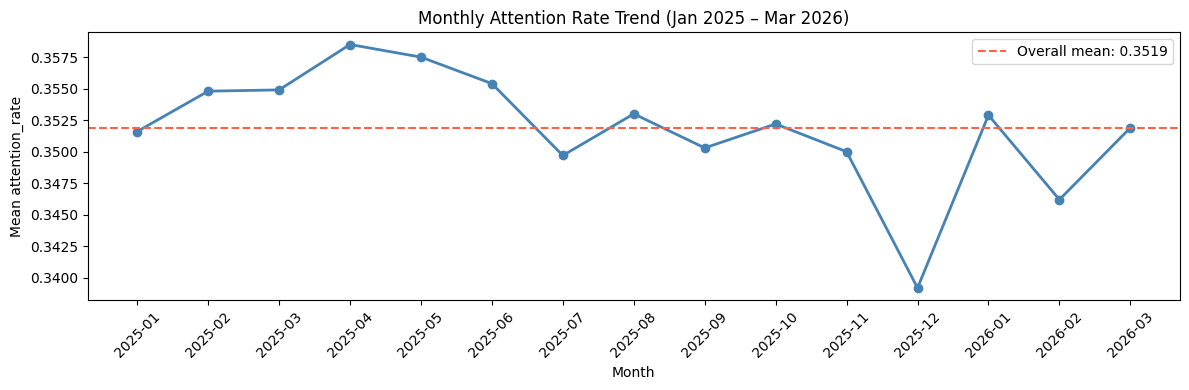

In [29]:
print("=== MONTHLY TREND: Is attention stable or declining? ===\n")

monthly = (
    cleaned_df.groupby("source_month")["attention_rate"]
    .mean().round(4).reset_index()
    .sort_values("source_month")
)
monthly["month_num"] = range(1, len(monthly)+1)

# Simple trend: first 3 months vs last 3 months
first_3 = monthly.head(3)["attention_rate"].mean()
last_3  = monthly.tail(3)["attention_rate"].mean()

print(f"First 3 months avg (Jan-Mar 2025): {first_3:.4f}")
print(f"Last 3 months avg (Jan-Mar 2026):  {last_3:.4f}")
print(f"Trend: {(last_3-first_3)*100:+.2f}pp over 15 months")
display(monthly[["source_month","attention_rate"]])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly["source_month"], monthly["attention_rate"],
        marker="o", linewidth=2, color="steelblue")
ax.axhline(monthly["attention_rate"].mean(), color="tomato",
           linestyle="--", label=f"Overall mean: {monthly['attention_rate'].mean():.4f}")
ax.set_title("Monthly Attention Rate Trend (Jan 2025 – Mar 2026)")
ax.set_xlabel("Month")
ax.set_ylabel("Mean attention_rate")
ax.tick_params(axis="x", rotation=45)
ax.legend()
fig.tight_layout()
plt.show()

In [30]:
# Who is co-viewing and does it affect attention?
print("=== CO-VIEWING ANALYSIS ===\n")

cleaned_df["has_coviewer"] = (cleaned_df["coview_seconds"] > 0).astype(int)

coview_summary = cleaned_df.groupby("has_coviewer").agg(
    row_count=("attention_rate", "count"),
    mean_attention_rate=("attention_rate", "mean"),
    mean_visible_rate=("visible_rate", "mean"),
    mean_engagement=("attention_given_visible", "mean"),
    pct_of_total=("attention_rate", "count")
).round(4)
coview_summary["pct_of_total"] = (
    coview_summary["pct_of_total"] / len(cleaned_df) * 100
).round(2)
display(coview_summary)

# Co-viewing by source type
print("\nCo-viewing rate by source type:")
display(cleaned_df.groupby("source_type")["has_coviewer"]
        .mean().round(4).reset_index()
        .rename(columns={"has_coviewer": "coview_rate"}))

# Co-viewing by daypart
print("\nCo-viewing rate by daypart:")
display(cleaned_df.groupby("daypart")["has_coviewer"]
        .mean().round(4).reset_index()
        .rename(columns={"has_coviewer": "coview_rate"})
        .sort_values("coview_rate", ascending=False))

=== CO-VIEWING ANALYSIS ===



,row_count,mean_attention_rate,mean_visible_rate,mean_engagement,pct_of_total
has_coviewer,,,,,
0,10723137,0.3205,0.6002,0.5228,71.49
1,4276387,0.4305,0.8145,0.5090,28.51



Co-viewing rate by source type:


,source_type,coview_rate
0,ctv,0.2657
1,linear,0.2852



Co-viewing rate by daypart:


,daypart,coview_rate
10,Prime Access,0.3422
1,Early Access,0.3242
5,Late News,0.3202
9,Prime,0.3159
2,Early Fringe,0.3115
4,Late Fringe,0.2715
0,Daytime,0.2638
6,Late Night,0.2368
3,Early Morning,0.2316
7,Morning,0.2212


In [31]:
# Viewers per household vs attention
print("=== HOUSEHOLD SIZE vs ATTENTION ===\n")

viewers_per_hh = (
    cleaned_df.groupby("hh_id")["demo_id"]
    .nunique()
    .reset_index()
    .rename(columns={"demo_id": "viewers_in_hh"})
)

cleaned_df_hh = cleaned_df.merge(viewers_per_hh, on="hh_id", how="left")

hh_size_attention = (
    cleaned_df_hh.groupby("viewers_in_hh")["attention_rate"]
    .agg(row_count="count", mean_attention="mean")
    .round(4)
    .reset_index()
    .sort_values("viewers_in_hh")
    .head(10)
)
display(hh_size_attention)
print("\nDo larger households pay more or less attention per viewer?")

=== HOUSEHOLD SIZE vs ATTENTION ===



,viewers_in_hh,row_count,mean_attention
0,1,5824036,0.3527
1,2,6417548,0.3561
2,3,1747410,0.3402
3,4,737034,0.3561
4,5,270795,0.2983
5,6,1252,0.2162
6,7,1449,0.2928



Do larger households pay more or less attention per viewer?


=== ATTENTION BY HOUR OF DAY ===



,hour_of_day,row_count,mean_attention_rate
0,0,334386,0.3275
1,1,190497,0.3069
2,2,125529,0.2943
3,3,95226,0.2909
4,4,103708,0.2988
5,5,137608,0.2889
6,6,248423,0.3068
7,7,435356,0.3287
8,8,490992,0.3310
9,9,520700,0.3306


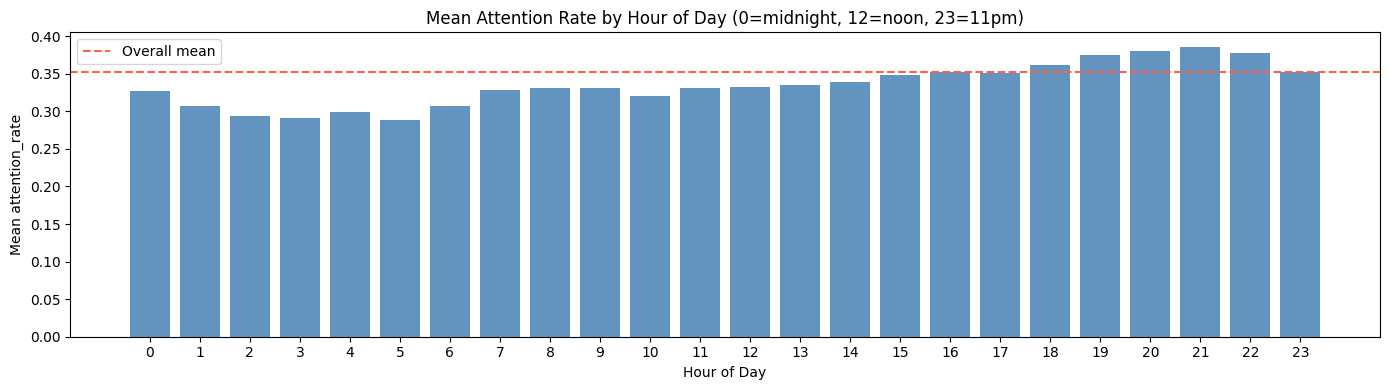


Best hours for CTV attention:


,hour_of_day,attention_rate
0,0,0.3492
2,2,0.3155
19,19,0.3146
21,21,0.3126
20,20,0.3124
22,22,0.3043
1,1,0.3015
23,23,0.2992


In [32]:
# Hour of day attention curve
print("=== ATTENTION BY HOUR OF DAY ===\n")

hourly = (
    cleaned_df.groupby("hour_of_day")["attention_rate"]
    .agg(row_count="count", mean_attention_rate="mean")
    .round(4)
    .reset_index()
    .sort_values("hour_of_day")
)
display(hourly)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(hourly["hour_of_day"], hourly["mean_attention_rate"],
       color="steelblue", alpha=0.85)
ax.axhline(cleaned_df["attention_rate"].mean(), color="tomato",
           linestyle="--", label="Overall mean")
ax.set_title("Mean Attention Rate by Hour of Day (0=midnight, 12=noon, 23=11pm)")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Mean attention_rate")
ax.set_xticks(range(0, 24))
ax.legend()
fig.tight_layout()
plt.show()

# Best hours for CTV specifically
print("\nBest hours for CTV attention:")
display(
    cleaned_df[cleaned_df["source_type"]=="ctv"]
    .groupby("hour_of_day")["attention_rate"]
    .mean().round(4).reset_index()
    .sort_values("attention_rate", ascending=False)
    .head(8)
)

=== AD FATIGUE: BRAND FREQUENCY vs ATTENTION ===



,exposure_count,viewers,avg_attention
0,1,790622,0.3406
1,2,381940,0.3369
2,3,204489,0.3402
3,4,135356,0.3419
4,5,92719,0.3422
5,6,70126,0.3456
6,7,53511,0.3446
7,8,42849,0.3440
8,9,34767,0.3465
9,10,28685,0.3477


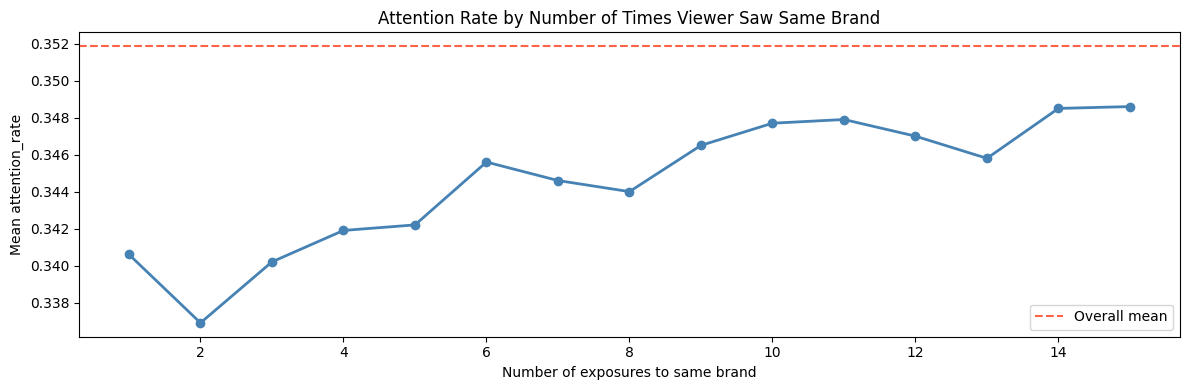


Does attention drop after multiple exposures to the same brand?


In [33]:
# Brand exposure frequency vs attention
print("=== AD FATIGUE: BRAND FREQUENCY vs ATTENTION ===\n")

brand_freq = (
    cleaned_df.groupby(["demo_id", "brand_name"])
    .agg(exposure_count=("attention_rate", "count"),
         mean_attention=("attention_rate", "mean"))
    .reset_index()
)

freq_attention = (
    brand_freq.groupby("exposure_count")["mean_attention"]
    .agg(viewers="count", avg_attention="mean")
    .round(4)
    .reset_index()
    .head(20)
)
display(freq_attention)

fig, ax = plt.subplots(figsize=(12, 4))
plot_data = freq_attention[freq_attention["exposure_count"] <= 15]
ax.plot(plot_data["exposure_count"], plot_data["avg_attention"],
        marker="o", linewidth=2, color="steelblue")
ax.set_title("Attention Rate by Number of Times Viewer Saw Same Brand")
ax.set_xlabel("Number of exposures to same brand")
ax.set_ylabel("Mean attention_rate")
ax.axhline(cleaned_df["attention_rate"].mean(), color="tomato",
           linestyle="--", label="Overall mean")
ax.legend()
fig.tight_layout()
plt.show()
print("\nDoes attention drop after multiple exposures to the same brand?")

=== SEASONAL ATTENTION TRENDS ===



,source_month,attention_rate,season
0,2025-01,0.3516,Winter
1,2025-02,0.3548,Winter
2,2025-03,0.3549,Spring
3,2025-04,0.3585,Spring
4,2025-05,0.3575,Spring
5,2025-06,0.3554,Summer
6,2025-07,0.3497,Summer
7,2025-08,0.3530,Summer
8,2025-09,0.3503,Fall
9,2025-10,0.3522,Fall



Average attention by season:


season
Spring     0.3557
Summer     0.3527
Winter     0.3514
Fall       0.3508
Holiday    0.3392
Name: attention_rate, dtype: float64

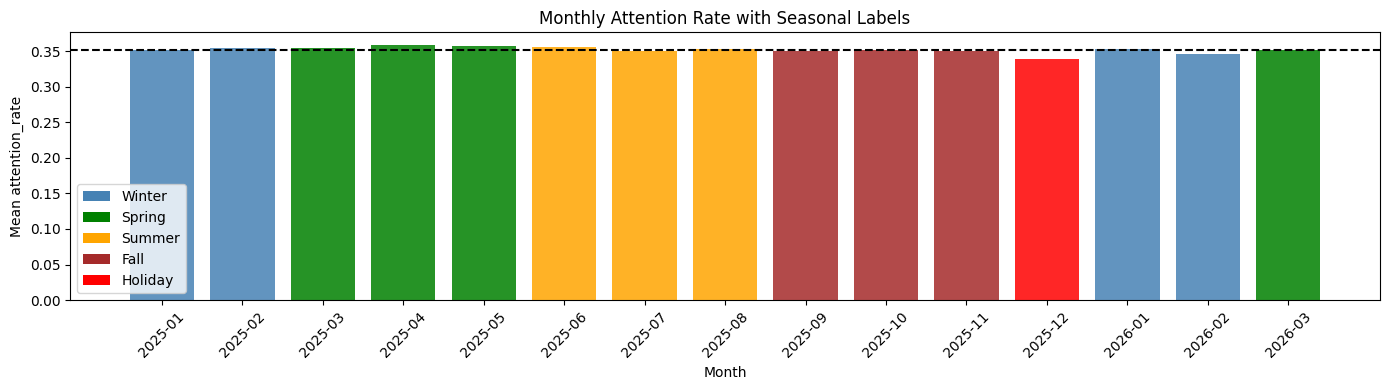

In [34]:
# Monthly attention with season labels
print("=== SEASONAL ATTENTION TRENDS ===\n")

monthly = (
    cleaned_df.groupby("source_month")["attention_rate"]
    .mean().round(4).reset_index()
    .sort_values("source_month")
)

season_map = {
    "2025-01": "Winter", "2025-02": "Winter", "2025-03": "Spring",
    "2025-04": "Spring", "2025-05": "Spring", "2025-06": "Summer",
    "2025-07": "Summer", "2025-08": "Summer", "2025-09": "Fall",
    "2025-10": "Fall",   "2025-11": "Fall",   "2025-12": "Holiday",
    "2026-01": "Winter", "2026-02": "Winter", "2026-03": "Spring"
}
monthly["season"] = monthly["source_month"].map(season_map)

display(monthly)

seasonal_avg = monthly.groupby("season")["attention_rate"].mean().round(4)
print("\nAverage attention by season:")
display(seasonal_avg.sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(14, 4))
colors = {"Winter":"steelblue","Spring":"green",
          "Summer":"orange","Fall":"brown","Holiday":"red"}
bar_colors = [colors[s] for s in monthly["season"]]
ax.bar(monthly["source_month"], monthly["attention_rate"],
       color=bar_colors, alpha=0.85)
ax.axhline(monthly["attention_rate"].mean(), color="black",
           linestyle="--", label="Overall mean")
ax.set_title("Monthly Attention Rate with Seasonal Labels")
ax.set_xlabel("Month")
ax.set_ylabel("Mean attention_rate")
ax.tick_params(axis="x", rotation=45)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k,v in colors.items()]
ax.legend(handles=legend_elements)
fig.tight_layout()
plt.show()

In [35]:
# Top and bottom brands by attention
print("=== TOP & BOTTOM BRANDS BY ATTENTION RATE ===\n")

brand_attention = (
    cleaned_df.groupby("brand_name")["attention_rate"]
    .agg(exposure_count="count", mean_attention="mean")
    .reset_index()
    .round(4)
)

# Only brands with meaningful sample (at least 10k exposures)
brand_attention_filtered = brand_attention[
    brand_attention["exposure_count"] >= 10000
].sort_values("mean_attention", ascending=False)

print("Top 15 brands by attention rate (min 10k exposures):")
display(brand_attention_filtered.head(15))

print("\nBottom 15 brands by attention rate (min 10k exposures):")
display(brand_attention_filtered.tail(15))

=== TOP & BOTTOM BRANDS BY ATTENTION RATE ===

Top 15 brands by attention rate (min 10k exposures):


,brand_name,exposure_count,mean_attention
5159,Game Show Network,12322,0.4100
3510,Cozi TV,23060,0.4075
2426,CNN,108457,0.3939
1474,Balsam Hill,13943,0.3915
5699,Hallmark Channel,20817,0.3883
8198,NBC,91661,0.3864
4865,Force Factor,17241,0.3843
2094,Bravo,61079,0.3839
321,AMC+,12064,0.3824
10832,Starbucks,10188,0.3812



Bottom 15 brands by attention rate (min 10k exposures):


,brand_name,exposure_count,mean_attention
2322,CABENUVA,14845,0.2899
125,4Patriots,12845,0.2898
1381,BIKTARVY,24287,0.2897
1023,Apretude,13448,0.2886
3315,Comcast Business,36024,0.2865
3202,Cobenfy,19293,0.2840
394,AUVELITY,19032,0.2835
9667,REXULTI,13321,0.2818
2623,CarShield,29498,0.2805
1396,BMW,38599,0.2770


In [36]:
# Top programs for ad attention
print("=== TOP PROGRAMS FOR AD ATTENTION ===\n")

program_attention = (
    cleaned_df.groupby(["program_name", "source_type"])["attention_rate"]
    .agg(exposure_count="count", mean_attention="mean")
    .reset_index()
    .round(4)
)

# Min 5k exposures
program_filtered = program_attention[
    program_attention["exposure_count"] >= 5000
]

print("Top 15 programs for ad attention:")
display(
    program_filtered.sort_values("mean_attention", ascending=False)
    .head(15)
)

print("\nTop 10 CTV programs specifically:")
display(
    program_filtered[program_filtered["source_type"]=="ctv"]
    .sort_values("mean_attention", ascending=False)
    .head(10)
)

=== TOP PROGRAMS FOR AD ATTENTION ===

Top 15 programs for ad attention:


,program_name,source_type,exposure_count,mean_attention
5561,Fox 4 News at 9PM,linear,7036,0.5511
15954,WESH 2 News at 6pm,linear,5261,0.5030
3008,Castle,linear,9559,0.4977
5827,George Lopez,linear,17639,0.4808
2375,Boston 25 Morning News at 7AM,linear,6226,0.4749
867,ABC 7 Eyewitness News @ 10P,linear,16612,0.4601
881,ABC 7 Eyewitness News @ 6P,linear,10868,0.4599
865,ABC 7 Eyewitness News 8am,linear,5545,0.4556
3614,Contraband: Seized at the Border,linear,7339,0.4469
3395,Chronicle,linear,5314,0.4393



Top 10 CTV programs specifically:


,program_name,source_type,exposure_count,mean_attention


In [37]:
# Attention Index — normalize to 100 = average
print("=== ATTENTION INDEX BY INDUSTRY ===\n")
print("(100 = average, >100 = above average, <100 = below average)\n")

overall_mean = cleaned_df["attention_rate"].mean()

attention_index = (
    cleaned_df.groupby("industry")["attention_rate"]
    .mean()
    .reset_index()
    .rename(columns={"attention_rate": "mean_attention"})
)
attention_index["attention_index"] = (
    attention_index["mean_attention"] / overall_mean * 100
).round(1)
attention_index = attention_index.sort_values("attention_index", ascending=False)
display(attention_index.round(4))

=== ATTENTION INDEX BY INDUSTRY ===

(100 = average, >100 = above average, <100 = below average)



,industry,mean_attention,attention_index
6,Entertainment / Media / Leisure,0.3682,104.6
0,Apparel / Footwear / Accessories,0.3672,104.3
19,Travel,0.3588,102.0
8,Food / Beverages,0.3551,100.9
2,Consumer Products,0.3534,100.4
15,Restaurants,0.3514,99.9
3,Cosmetic / Hygiene,0.3501,99.5
16,Retail,0.3492,99.2
1,Automotive / Vehicles,0.3465,98.5
18,Telecommunications,0.3464,98.5


cat > /home/capstone/FT2026/TVision/findings_report.md << 'EOF'
# TVision CTV Attention Analysis — Key Findings Report
**MSBA Capstone | Rady School of Management, UC San Diego**
**Data: Jan 2025 – Mar 2026 | 15,000,000 ad exposures**

---

## 1. Data Cleaning
Before any analysis we applied three corrections. Age was capped to [5–80], removing 479,680 invalid values. Attention seconds and visible seconds were both capped at ad duration, fixing 112,096 and 317,515 overruns respectively. Without these fixes, rate metrics would be artificially inflated and incomparable across ads of different lengths.

---

## 2. Overall KPIs (Weighted)
Attention Rate **35.3%** | Visibility Rate **66.3%** | Attention Given Visible **51.9%**

Weights barely shifted unweighted numbers by only +0.12pp, confirming the panel is broadly representative of the real viewing population.

---

## 3. CTV vs Linear — The Core Platform Finding

| Platform | Attention | Visibility | Engagement |
|---|---|---|---|
| Linear | 35.2% | 66.2% | 51.8% |
| CTV | 28.1% | 50.3% | 53.5% |
| Gap | +7.1pp | +15.9pp | −1.8pp |

CTV's problem is delivery, not audience quality. Linear ads appear on screen 15.9pp more often. But when a CTV ad IS visible, viewers pay 1.8pp MORE attention than on Linear. Fixing CTV viewability would close most of the 7pp gap — this is a product opportunity, not an audience problem.

---

## 4. Best vs Worst Advertising Conditions

| Scenario | Attention | vs Average |
|---|---|---|
| Worst: Overnight, CTV, no match | 25.3% | −9.9pp |
| Average: all ads | 35.2% | baseline |
| Good: Prime, Linear, no match | 37.3% | +2.1pp |
| Better: Prime Access, Linear, matched | 39.8% | +4.6pp |
| Best: Prime Access, Linear, matched, 65–80 | 40.6% | +5.4pp |

The gap between worst and best conditions is 15.3pp — nearly a 60% improvement in attention. Advertisers have significant control over their outcomes purely through smarter placement decisions.

---

## 5. Daypart Rankings

| Daypart | Attention Rate |
|---|---|
| Prime Access | **39.0%** |
| Late News | 38.3% |
| Prime | 38.1% |
| Early Access | 37.4% |
| Daytime | 33.7% |
| Overnight | **29.4%** |

Daypart is the single strongest driver of attention at 37.7% feature importance in XGBoost. Moving from Overnight to Prime Access alone yields a +9.6pp lift — a 33% relative improvement. Prime Access outperforms even Prime itself likely because audiences are settling in before peak programming begins.

---

## 6. Hour of Day
Attention peaks at 9PM (38.6%) and 8PM (38.1%). Worst hours are 5AM (28.9%) and 3–4AM (29.1%). Hourly granularity is more actionable than broad daypart labels for precise ad scheduling.

---

## 7. Contextual Match

Overall match rate: **40.2%** of exposures | Overall lift: **+0.81pp** attention

| Daypart | Lift |
|---|---|
| Prime Access | **+2.10pp** |
| Prime | +1.44pp |
| Early Morning | +1.12pp |
| Overnight | −1.31pp |

Contextual alignment amplifies existing engagement rather than creating it. It works in high-attention dayparts and reverses in low-attention ones. At 15M exposures per month, +0.81pp translates to 121,500 additional attention-seconds per month at scale.

---

## 8. Contextual Match × Platform (XGBoost)

| Platform | Contextual Lift |
|---|---|
| CTV | **+0.16pp** |
| Linear | −0.03pp |

This is one of the most important findings. Contextual matching only helps CTV — it does nothing positive for Linear TV. CTV viewers are more intentional in their content choices so ad-content alignment resonates more strongly. Contextual targeting should be positioned as a CTV-specific tool, not a general TV strategy.

---

## 9. Co-Viewing — The Biggest Single Lift Factor

| | Attention | Visibility |
|---|---|---|
| No co-viewer | 32.1% | 60.0% |
| Co-viewer present | **43.1%** | **81.5%** |
| Lift | **+11.0pp** | **+21.5pp** |

Co-viewing produces the largest attention lift of any variable in the entire analysis — bigger than contextual match, bigger than daypart, bigger than age. 28.5% of all ad exposures have a co-viewer present. Prime Access has the highest co-viewing rate at 34.2%. Co-viewed ads reach multiple people simultaneously AND at dramatically higher attention levels — a double multiplier that standard reach metrics miss entirely.

---

## 10. Age

| Age Group | Attention |
|---|---|
| 5–17 | 25.3% |
| 18–24 | 27.1% |
| 35–44 | 30.2% |
| 45–54 | 32.8% |
| 55–64 | 35.5% |
| 65–80 | **38.1%** |

Age was the strongest numeric predictor in OLS with a t-statistic of 355. XGBoost revealed the relationship is non-linear — attention stays flat until around age 55 then jumps sharply. The 18–24 group has the largest CTV deficit at 13.4pp below Linear, meaning young viewers are specifically disengaged from CTV ads.

---

## 11. Ad Fatigue — Conventional Wisdom is Wrong
Attention does NOT drop with repeated brand exposure. It starts at 34.1% on first exposure and slightly increases to around 34.9% at 10+ exposures. Advertisers worried about over-frequency can be reassured that repeated exposure does not harm attention quality in this dataset.

---

## 12. Seasonal Trends

| Season | Attention |
|---|---|
| Spring | **35.6%** |
| Summer | 35.3% |
| Winter | 35.1% |
| Fall | 35.1% |
| Holiday (December) | **33.9%** |

Overall trend: −0.34pp over 15 months — essentially flat. The December holiday dip is counterintuitive — the highest ad spend month produces the lowest attention, suggesting advertising clutter during the holidays reduces individual ad attention even as total viewership rises.

---

## 13. Industry Attention Index (100 = average)

| Industry | Index |
|---|---|
| Entertainment / Media / Leisure | **104.6** |
| Apparel / Footwear | 104.3 |
| Travel | 102.0 |
| Health | 96.3 |
| Education | 92.7 |
| Insurance | **52.9** |

Entertainment and apparel outperform because their content naturally aligns with the entertainment programming environment. Pharmaceutical brands consistently rank at the bottom of brand-level performance, concentrated in news and daytime contexts where general audience attention is already lower.

---

## 14. OLS Regression Results
**14,520,712 observations | Weighted OLS | R² = 1.5%**

Top positive drivers: Broadcast (+5.1pp), Late News daypart (+4.7pp), Prime daypart (+4.3pp), Linear vs CTV (+3.8pp)

Top negative drivers: News channel content (−12.3pp), Sports channel (−7.9pp), Spanish Language (−6.1pp), Overnight (−3.7pp)

R² of 1.5% is normal and expected for individual-level attention data in media research. All 46 significant coefficients have p < 0.001 — the directional findings are statistically solid at this sample size.

---

## 15. XGBoost Model
**R² = 3.4% vs OLS 1.5% — 123% more accurate**

| Feature | Importance |
|---|---|
| Daypart | **37.7%** |
| Source Category | 23.0% |
| Industry | 15.2% |
| Age | 6.3% |
| Gender | 3.8% |
| Source Type (CTV vs Linear) | 2.8% |
| Contextual Match | 0.86% |

When and where an ad airs accounts for over 60% of all predictable attention variance. Contextual match is last but statistically real — it is a precise tool, not a dominant one.

---

## 16. Top Programs and Brands

Top programs by attention: Fox 4 News at 9PM (55.1%), WESH 2 News at 6pm (50.3%), Castle (49.8%), George Lopez (48.1%). Local news dominates because viewers are actively engaged with locally relevant information and ad breaks fall at natural pause points.

Top brands: Game Show Network (41.0%), Cozi TV (40.8%), CNN (39.4%), NBC (38.6%), CBS (38.1%). Network promotional ads lead because they air in their own programming environment where audience alignment is automatic.

Bottom brands: Pharmaceutical and direct-response advertisers — industries relying on broad reach rather than targeted placement, airing in cheaper low-attention inventory.

---

## 17. Consolidated Recommendations

**1. Shift budget to Prime Access and Prime** — +9.6pp attention lift vs Overnight, the single highest ROI scheduling change available.

**2. Fix CTV delivery before adding CTV spend** — the audience is engaged, the ads just are not appearing on screen. Viewability improvement closes most of the 7pp gap.

**3. Apply contextual matching to CTV only** — it lifts CTV by +0.16pp and has no positive effect on Linear. Combine with Prime Access for maximum +2.1pp lift.

**4. Prioritize co-viewing contexts** — +11pp attention lift is the biggest effect in the entire analysis. Prime Access has the highest co-viewing rate at 34.2%.

**5. Target 55+ on Linear in Prime Access** — highest attention demographic (38.1%) in the highest attention daypart (39.0%) on the highest attention platform.

**6. Avoid News and Sports channel inventory** — −12.3pp OLS penalty despite high viewership. Broadcast outperforms cable news significantly.

**7. Weight campaigns toward Spring** — best attention season at 35.6%. December holiday clutter reduces attention to its annual low of 33.9% despite being peak ad spend season.

--
